<h2>Formating of DB-Data<h2>

In [1]:
from hilfsfunktionen.formating import get_unchanged_table, get_formated_table, get_table_with_keys, create_n_sentences
df_collection = {}
df_collection["unchanged_table"] = get_unchanged_table()
df_collection["formated_table"] = get_formated_table()
df_collection["formated_table_with_keys"] = get_table_with_keys(df_collection["formated_table"])
df_collection["n_sentences"] = {}
for n in [1, 5, 20, 50, 100]:
    df_collection["n_sentences"][f"{n}"] = create_n_sentences(df_collection["formated_table_with_keys"], n)

df_collection["formated_table"].head

<bound method NDFrame.head of                 credit_score          country         gender  \
0          Credit_Score_Fair   Country_France  Gender_Female   
1          Credit_Score_Fair    Country_Spain  Gender_Female   
2          Credit_Score_Poor   Country_France  Gender_Female   
3          Credit_Score_Good   Country_France  Gender_Female   
4     Credit_Score_Excellent    Country_Spain  Gender_Female   
...                      ...              ...            ...   
9995  Credit_Score_Very_Good   Country_France    Gender_Male   
9996       Credit_Score_Poor   Country_France    Gender_Male   
9997       Credit_Score_Good   Country_France  Gender_Female   
9998  Credit_Score_Very_Good  Country_Germany    Gender_Male   
9999  Credit_Score_Very_Good   Country_France  Gender_Female   

                            age     tenure            balance  \
0     Age_Adults_in_their_Prime   Tenure_2  Balance_Cluster_1   
1     Age_Adults_in_their_Prime   Tenure_1  Balance_Cluster_4   
2     

<h2>Model Creation<h2>

In [2]:
from hilfsfunktionen.model_training import (
    ModelConfig, 
    ModelTrainer, 
    ModelRepository, 
    ExperimentRunner
)
from pathlib import Path

seeds = [1, 42]

trainer = ModelTrainer()
repository = ModelRepository(base_dir=Path.cwd())

models = {}  
categories = {} 

# Führe Experimente durch
for seed in seeds:
    base_config = ModelConfig(
        vector_size = 50,      # Dimension der Wortvektoren; guter Kompromiss zwischen Ausdrucksstärke und Rechenaufwand
        window = 4,             # Kleines Kontextfenster; betont lokale, eher syntaktische Beziehungen
        epochs = 30,            # Viele Trainingsdurchläufe; bessere Anpassung, aber erhöhtes Overfitting-Risiko
        min_count = 1,          # Alle Wörter werden berücksichtigt; seltene Wörter sind jedoch oft verrauscht
        negative = 5,           # Anzahl negativer Beispiele; Standardwert mit gutem Qualitäts-/Zeit-Verhältnis
        sample = 0,             # Subsampling häufiger Wörter; verbessert Semantik, kann bei kleinen Korpora schaden
        hs = 0,                 # Hierarchical Softmax deaktiviert; Training erfolgt ausschließlich via Negative Sampling
        alpha = 0.025,          # Start-Lernrate; stabiler Trainingsbeginn, bei vielen Epochen kritisch
        seed = seed,               # Faester Zufallsstart; sorgt für Reproduzierbarkeit   
    )
    runner = ExperimentRunner(trainer, repository, base_config)
    models[seed], categories[seed] = runner.create_many_models(
        sentences=df_collection["n_sentences"]["20"],
        n_sentences_tokenized=df_collection["n_sentences"],
        n_used_sentences=10000, # Begrenzung der Trainingssätze; beschleunigt Training, limitiert Informationsgehalt
        verbose=True
    )
    

Model Creation started.
...Creating sentence models...
Started Model-Creation with: CBOW, vs=50, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_50_win_4_ep_30_nsent_10000_sentlen_17_mc_1_neg_5_sample_0_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: SGNS, vs=50, win=4, ep=30
Modell geladen: /workspace/models/SGNS_vs_50_win_4_ep_30_nsent_10000_sentlen_17_mc_1_neg_5_sample_0_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: CBOW, vs=50, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_50_win_4_ep_30_nsent_10000_sentlen_85_mc_1_neg_5_sample_0_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: SGNS, vs=50, win=4, ep=30
Modell geladen: /workspace/models/SGNS_vs_50_win_4_ep_30_nsent_10000_sentlen_85_mc_1_neg_5_sample_0_hs_0_alpha_0.025_seed_1.model
Loaded model.
Started Model-Creation with: CBOW, vs=50, win=4, ep=30
Modell geladen: /workspace/models/CBOW_vs_50_win_4_ep_30_nsent_10000_sentlen_340_mc_1_neg_5_sa

<h2>Durchschnittliche Satzvektoren berechnen<h2>

In [3]:
from hilfsfunktionen.sentence_vectors import create_average_sentence_vectors

average_sentence_vectors = {}

for seed in seeds:
    if seed not in average_sentence_vectors:
        average_sentence_vectors[seed] = {}
    for category in categories[seed]:  
        print(f"(-------------Vector calculation of category: {category.upper()}-------------)")
        
        if category not in average_sentence_vectors[seed]:
            average_sentence_vectors[seed][category] = []
        
        for model in models[seed][category]:
            vectors = create_average_sentence_vectors(
                model, 
                df_collection["formated_table_with_keys"], 
                base_dir=Path.cwd(), 
                verbose=False
            )
            average_sentence_vectors[seed][category].append([vectors, model[1]])
        
        print(f"(-------------Finished Vector calculation of category: {category.upper()}-------------)")

(-------------Vector calculation of category: SENTENCE-------------)
(-------------Finished Vector calculation of category: SENTENCE-------------)
(-------------Vector calculation of category: VECTOR-------------)
(-------------Finished Vector calculation of category: VECTOR-------------)
(-------------Vector calculation of category: WINDOWSIZE-------------)
(-------------Finished Vector calculation of category: WINDOWSIZE-------------)
(-------------Vector calculation of category: EPOCH-------------)
(-------------Finished Vector calculation of category: EPOCH-------------)
(-------------Vector calculation of category: NEGATIVE-------------)
(-------------Finished Vector calculation of category: NEGATIVE-------------)
(-------------Vector calculation of category: SAMPLE-------------)
(-------------Finished Vector calculation of category: SAMPLE-------------)
(-------------Vector calculation of category: HS-------------)
(-------------Finished Vector calculation of category: HS--------

<h2>Vektoren-Test Textbasiert<h2>

In [4]:
from hilfsfunktionen.collect_test_data import get_all_sweep_results
    
test_results = get_all_sweep_results(average_sentence_vectors, models, df_collection["formated_table_with_keys"] , verbose=False)

(-------------Test of category: SENTENCE-------------)

(-------------Test of category: VECTOR-------------)

(-------------Test of category: WINDOWSIZE-------------)

(-------------Test of category: EPOCH-------------)

(-------------Test of category: NEGATIVE-------------)

(-------------Test of category: SAMPLE-------------)

(-------------Test of category: HS-------------)

(-------------Test of category: ALPHA-------------)

Tests abgeschlossen. 192 Modelle getestet.


In [5]:
i=0
category:str = ""
for test_result in test_results:
    if category != test_result['params']['Test_Category']:
        print(test_result)
        print(test_result['params']['Test_Category'])
        category = test_result['params']['Test_Category']
        print("\n")
    i += 1

{'params': {'Vector Size': 50, 'Window': 4, 'Algorithmus': 'CBOW', 'Kleinste Worthäufigkeit': 1, 'Workers': 4, 'Epochs': 30, 'Satzanzahl': 10000, 'Satzlänge': 17, 'Negative Sampling': 5, 'Sample': 0, 'Hierarchical Softmax': 0, 'Alpha': 0.025, 'Test_Category': 'sentence'}, 'nd': np.float32(0.4814837), 'rs_mean': np.float64(0.714523196342037), 'rs_5': 0.7255952380952383, 'rs_10': 0.6931302031302031, 'rs_20': 0.7248441478006694, 'fc': 0.7017373546649429, 'kvc': {'model_score': np.float64(0.03492929292929293), 'avg_proximity_score': np.float64(0.03818181818181818), 'avg_weighted_proximity_score': np.float64(0.03492929292929293), 'total_found_values': 21, 'total_possible_values': 550, 'overall_recall': 0.038181818181818185, 'keys_evaluated': 50, 'topn': 20, 'filter_keys': True, 'max_fetch': 10000, 'interpretation': 'Ungenügend - Keys kodieren ihre Zeilenwerte kaum', 'individual_results': [{'key': np.str_('key_8082'), 'proximity_score': 0.09090909090909091, 'weighted_proximity_score': 0.0909

<h2>Visualisierung<h2>

=== COMPREHENSIVE METRICS COMPARISON ===


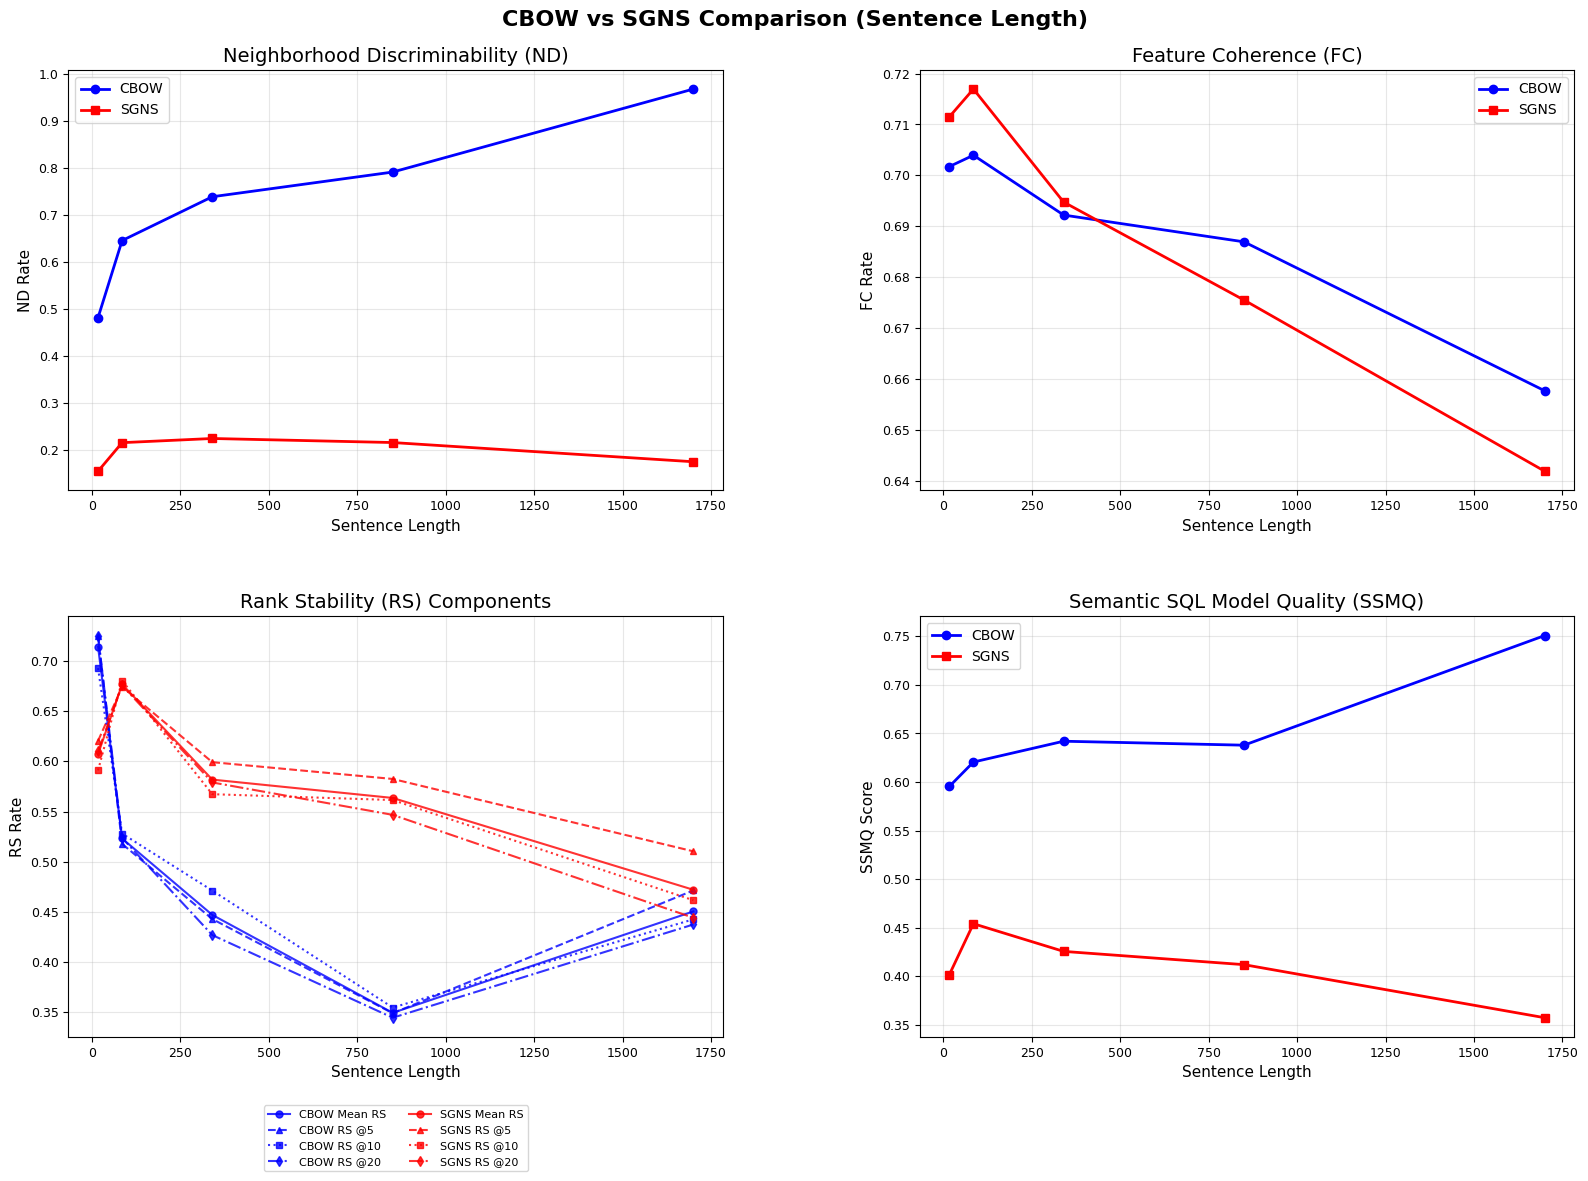


COMPREHENSIVE DATA FOR CATEGORY: SENTENCE

MAIN METRICS SUMMARY:
--------------------------------------------------------------------------------
Sentence Length CBOW:                     SGNS:                    
                ND       FC       SSMQ     ND       FC       SSMQ    
--------------------------------------------------------------------------------
17              0.4815   0.7017   0.5954   0.1543   0.7115   0.4016  
85              0.6457   0.704    0.6206   0.2151   0.717    0.454   
340             0.7391   0.6922   0.642    0.224    0.6948   0.4255  
850             0.7917   0.687    0.638    0.2154   0.6755   0.4119  
1700            0.9685   0.6577   0.7509   0.1744   0.6419   0.3572  

DETAILED RANK STABILITY (RS) COMPONENTS:
----------------------------------------------------------------------------------------------------
Sentence Length CBOW RS COMPONENTS:                           SGNS RS COMPONENTS:                          
                Mean     @5      

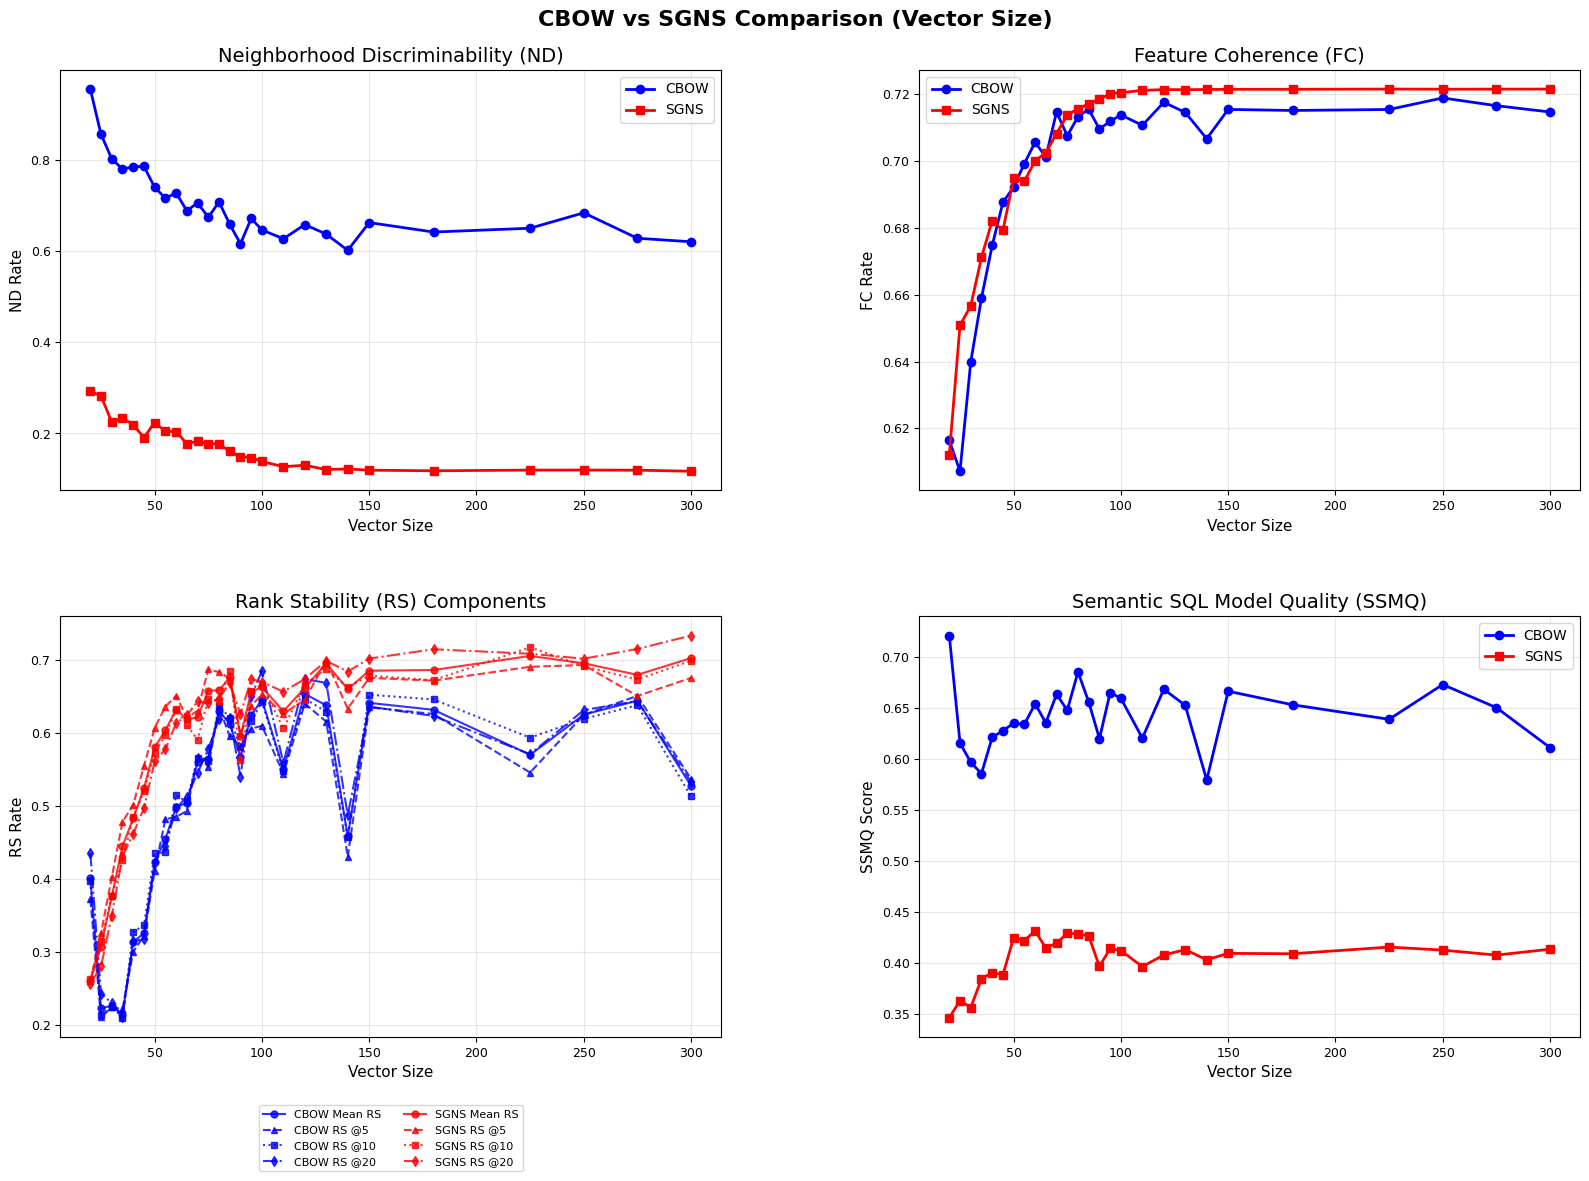


COMPREHENSIVE DATA FOR CATEGORY: VECTOR

MAIN METRICS SUMMARY:
--------------------------------------------------------------------------------
Vector Size     CBOW:                     SGNS:                    
                ND       FC       SSMQ     ND       FC       SSMQ    
--------------------------------------------------------------------------------
20              0.9545   0.6164   0.7208   0.2924   0.612    0.3465  
25              0.855    0.6072   0.6156   0.2823   0.6509   0.3633  
30              0.8015   0.6399   0.5966   0.2247   0.6566   0.3564  
35              0.7792   0.659    0.5856   0.2338   0.6711   0.3845  
40              0.7841   0.6747   0.6211   0.2192   0.6821   0.3907  
45              0.7853   0.6876   0.6277   0.191    0.6792   0.3885  
50              0.7391   0.6922   0.6348   0.224    0.6948   0.4249  
55              0.7155   0.6992   0.6339   0.2045   0.6939   0.422   
60              0.7268   0.7056   0.654    0.2043   0.7      0.4316  
65    

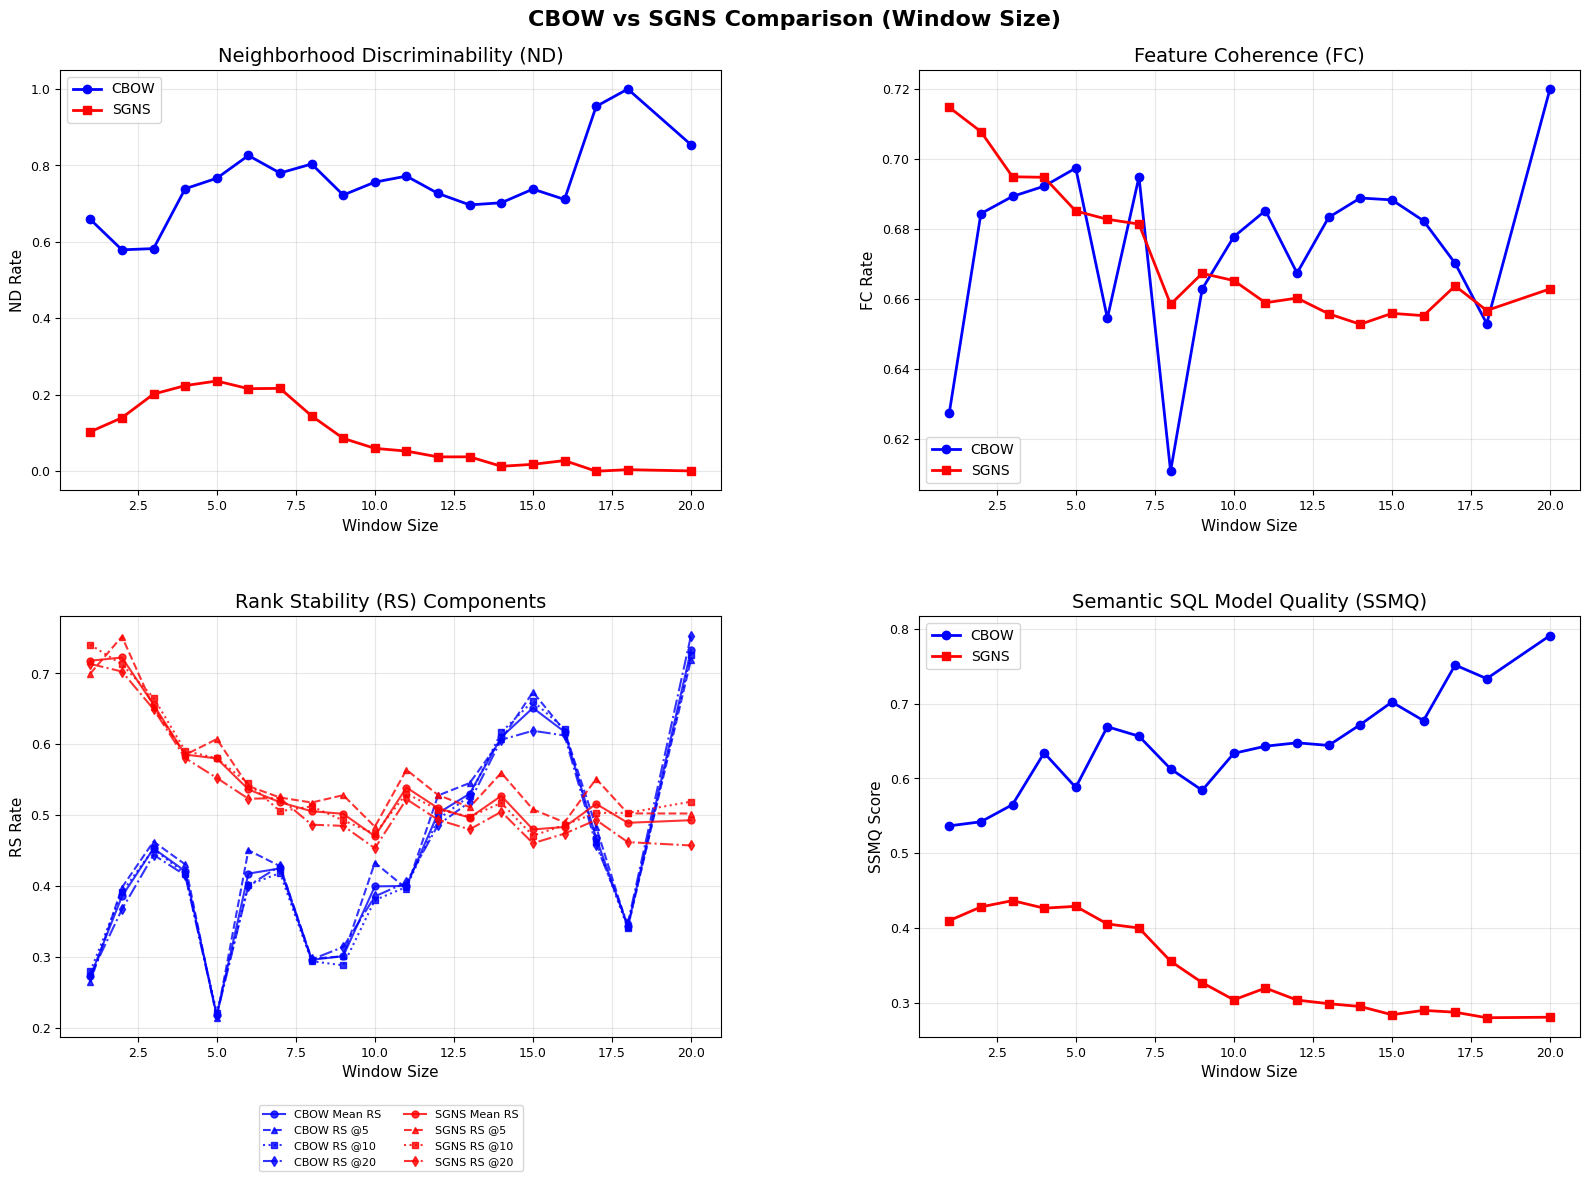


COMPREHENSIVE DATA FOR CATEGORY: WINDOWSIZE

MAIN METRICS SUMMARY:
--------------------------------------------------------------------------------
Window Size     CBOW:                     SGNS:                    
                ND       FC       SSMQ     ND       FC       SSMQ    
--------------------------------------------------------------------------------
1               0.6589   0.6273   0.5367   0.1033   0.7148   0.41    
2               0.5793   0.6844   0.5421   0.1399   0.7078   0.4283  
3               0.5826   0.6893   0.565    0.2019   0.6949   0.4367  
4               0.7391   0.6922   0.6343   0.224    0.6948   0.4266  
5               0.7666   0.6974   0.5881   0.2361   0.6851   0.4291  
6               0.8261   0.6544   0.6692   0.216    0.6827   0.4055  
7               0.7802   0.6949   0.6566   0.2168   0.6814   0.4001  
8               0.8039   0.6106   0.6128   0.1447   0.6584   0.3557  
9               0.7227   0.6628   0.5842   0.086    0.6673   0.327   
10

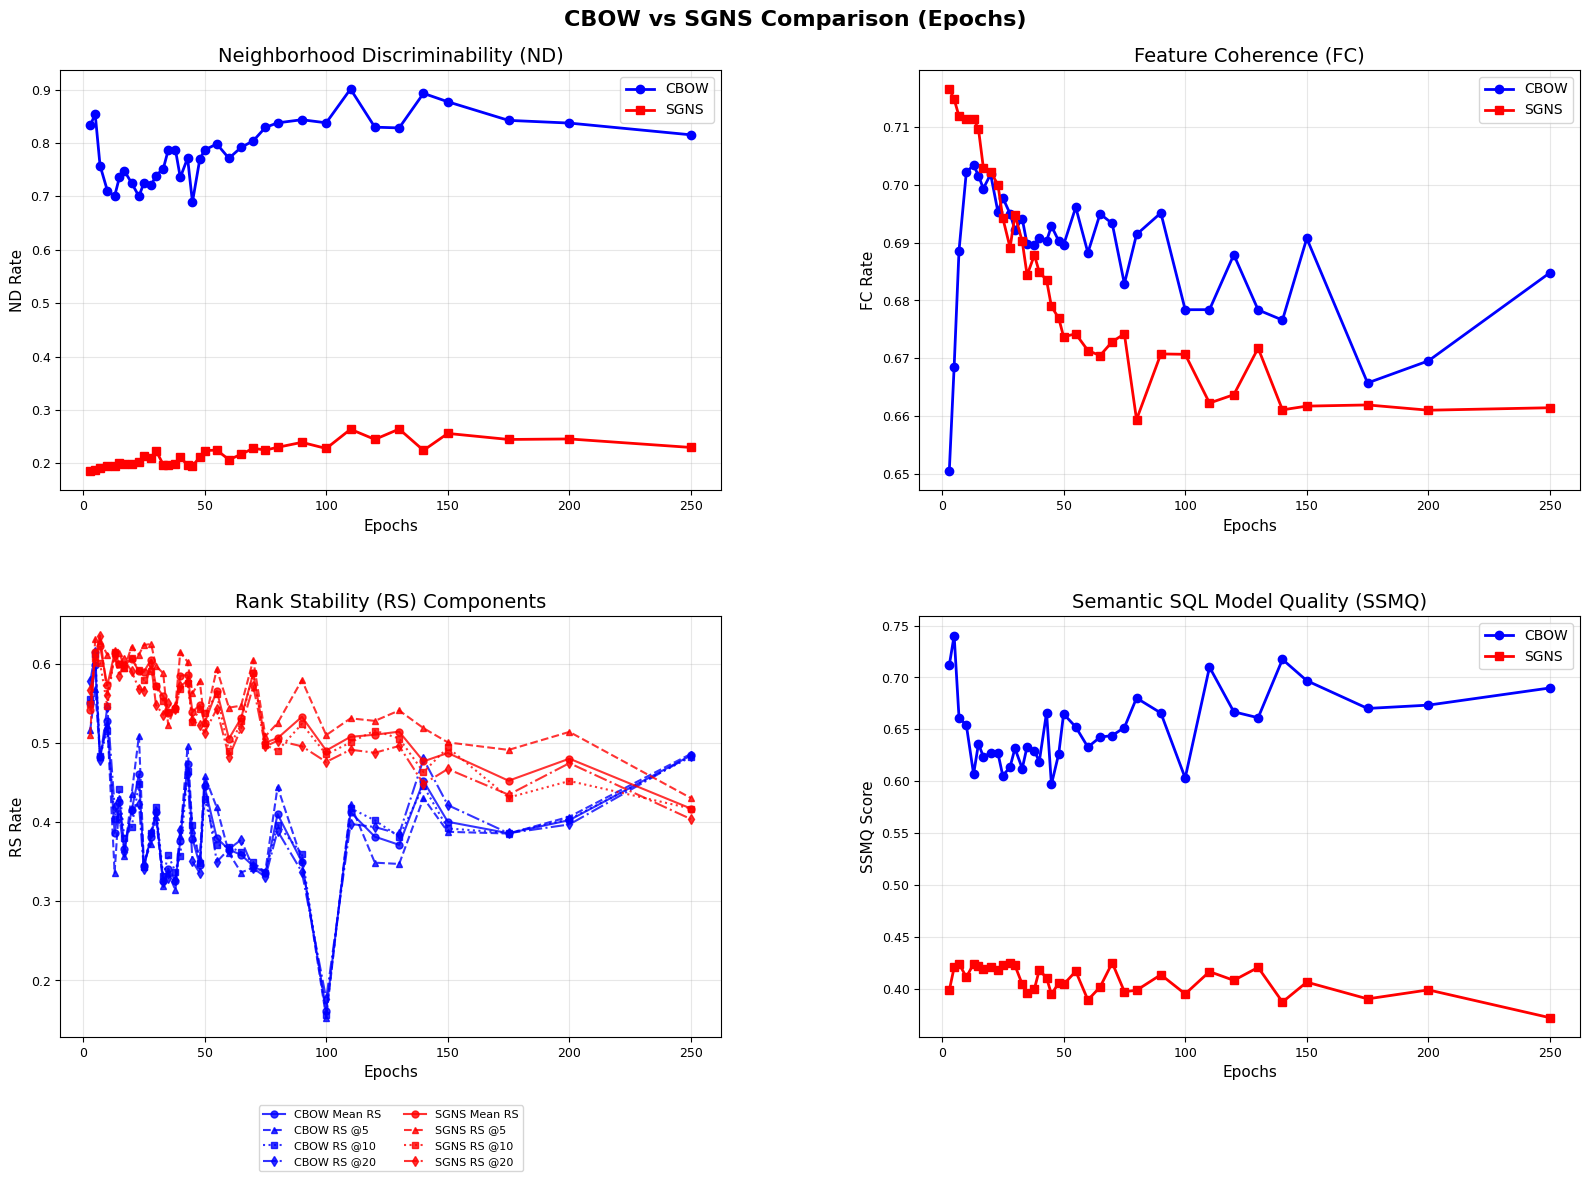


COMPREHENSIVE DATA FOR CATEGORY: EPOCH

MAIN METRICS SUMMARY:
--------------------------------------------------------------------------------
Epochs          CBOW:                     SGNS:                    
                ND       FC       SSMQ     ND       FC       SSMQ    
--------------------------------------------------------------------------------
3               0.8333   0.6505   0.7118   0.1853   0.7165   0.3986  
5               0.8543   0.6686   0.7404   0.187    0.7148   0.4208  
7               0.7579   0.6886   0.6613   0.191    0.7118   0.4245  
10              0.711    0.7022   0.6543   0.1946   0.7114   0.4114  
13              0.7006   0.7034   0.6069   0.1955   0.7114   0.4242  
15              0.7364   0.7016   0.6362   0.2005   0.7096   0.422   
17              0.7479   0.6994   0.6238   0.1985   0.703    0.4192  
20              0.725    0.7018   0.6273   0.1984   0.7022   0.4216  
23              0.7002   0.6953   0.6272   0.2031   0.7      0.4187  
25     

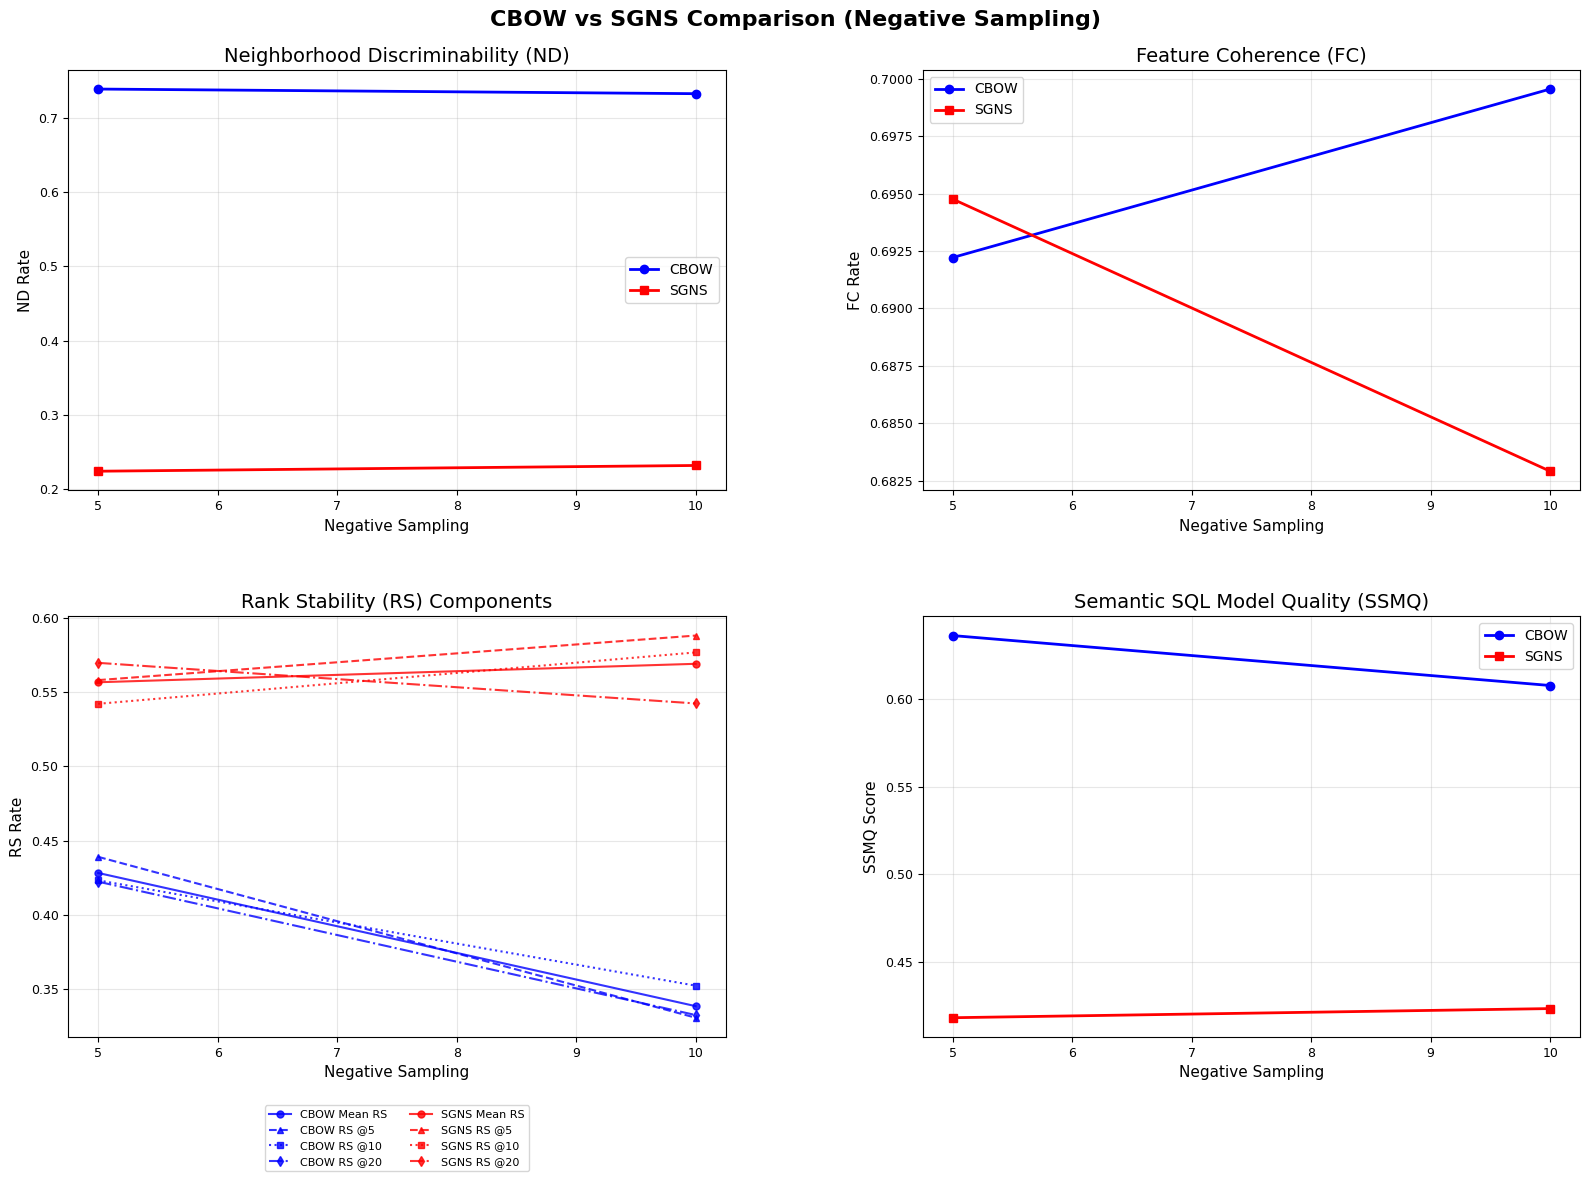


COMPREHENSIVE DATA FOR CATEGORY: NEGATIVE

MAIN METRICS SUMMARY:
--------------------------------------------------------------------------------
Negative Sampling CBOW:                     SGNS:                    
                ND       FC       SSMQ     ND       FC       SSMQ    
--------------------------------------------------------------------------------
5               0.7391   0.6922   0.6364   0.224    0.6948   0.4179  
10              0.7328   0.6996   0.6079   0.2318   0.6829   0.4232  

DETAILED RANK STABILITY (RS) COMPONENTS:
----------------------------------------------------------------------------------------------------
Negative Sampling CBOW RS COMPONENTS:                           SGNS RS COMPONENTS:                          
                Mean     @5       @10      @20      Mean     @5       @10      @20     
----------------------------------------------------------------------------------------------------
5               0.4282   0.439    0.4232   0.4223 

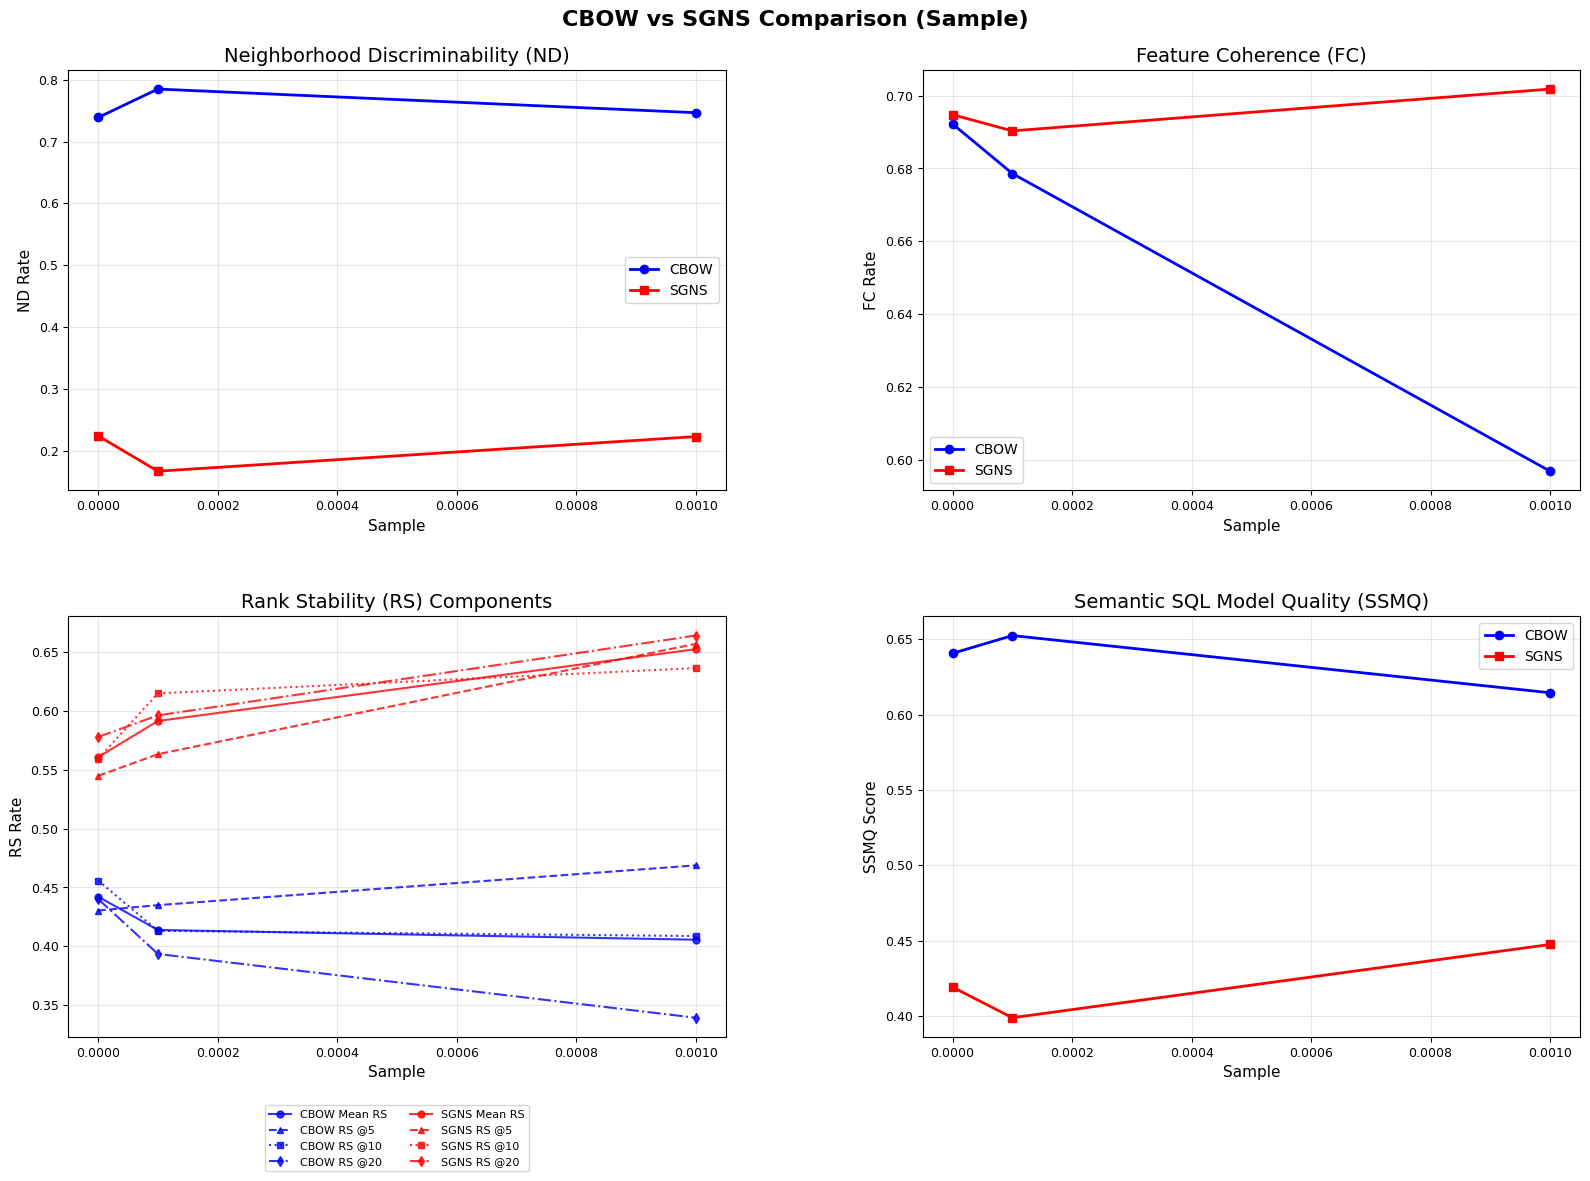


COMPREHENSIVE DATA FOR CATEGORY: SAMPLE

MAIN METRICS SUMMARY:
--------------------------------------------------------------------------------
Sample          CBOW:                     SGNS:                    
                ND       FC       SSMQ     ND       FC       SSMQ    
--------------------------------------------------------------------------------
0               0.7391   0.6922   0.6406   0.224    0.6948   0.4192  
0.0001          0.7851   0.6786   0.6524   0.1668   0.6903   0.3989  
0.001           0.7468   0.5969   0.6145   0.2228   0.7018   0.4475  

DETAILED RANK STABILITY (RS) COMPONENTS:
----------------------------------------------------------------------------------------------------
Sample          CBOW RS COMPONENTS:                           SGNS RS COMPONENTS:                          
                Mean     @5       @10      @20      Mean     @5       @10      @20     
---------------------------------------------------------------------------------------

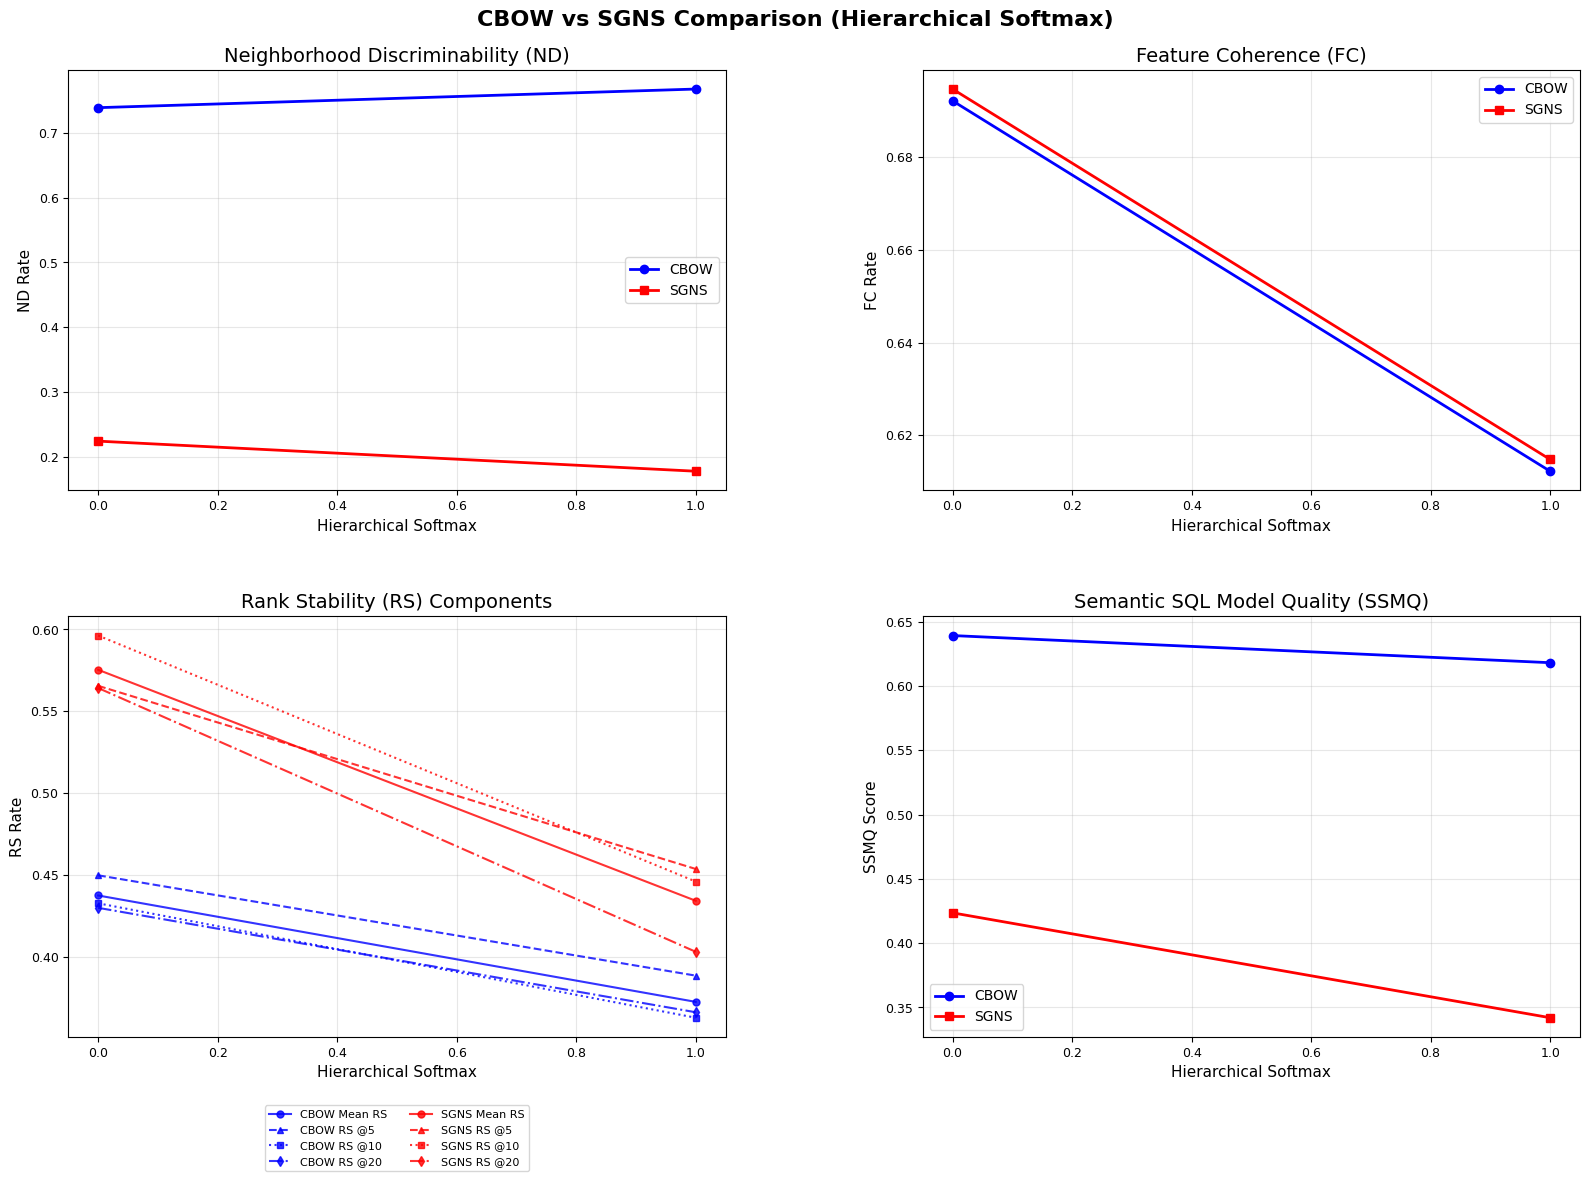


COMPREHENSIVE DATA FOR CATEGORY: HS

MAIN METRICS SUMMARY:
--------------------------------------------------------------------------------
Hierarchical Softmax CBOW:                     SGNS:                    
                ND       FC       SSMQ     ND       FC       SSMQ    
--------------------------------------------------------------------------------
0               0.7391   0.6922   0.6392   0.224    0.6948   0.4236  
1               0.7678   0.6122   0.6181   0.1775   0.6148   0.342   

DETAILED RANK STABILITY (RS) COMPONENTS:
----------------------------------------------------------------------------------------------------
Hierarchical Softmax CBOW RS COMPONENTS:                           SGNS RS COMPONENTS:                          
                Mean     @5       @10      @20      Mean     @5       @10      @20     
----------------------------------------------------------------------------------------------------
0               0.4375   0.4498   0.4327   0.43   

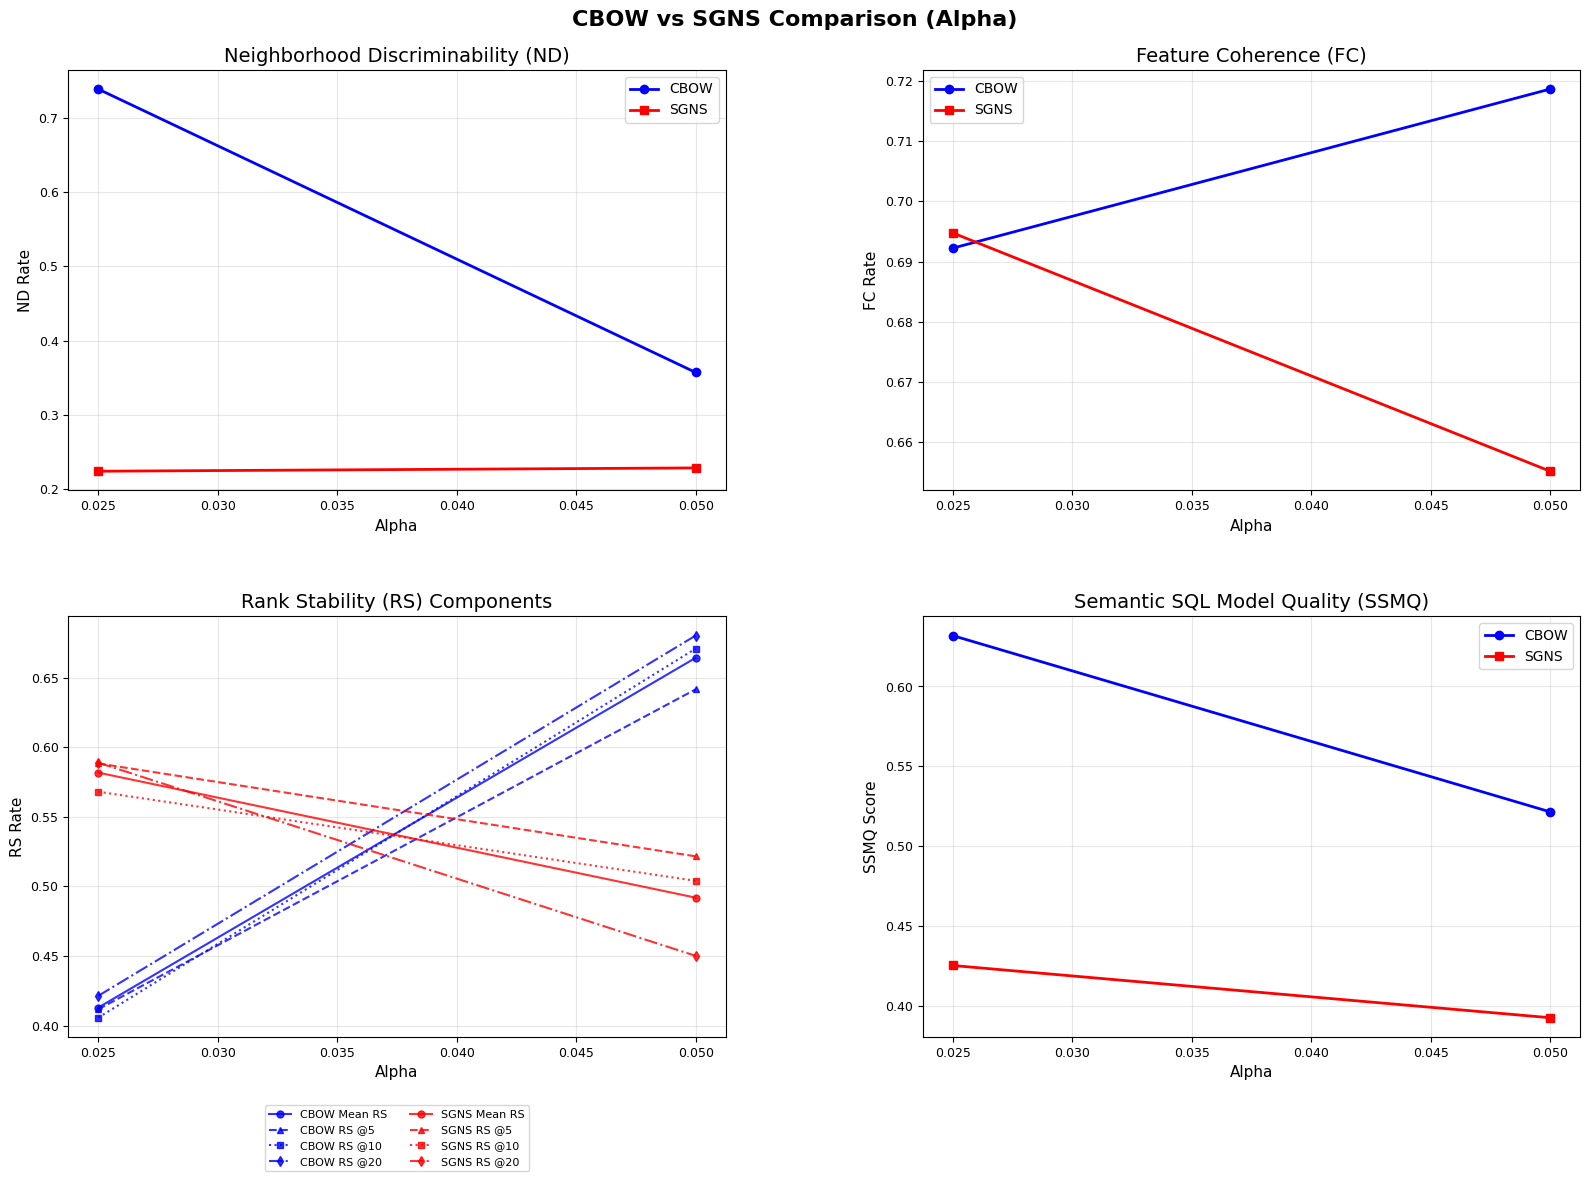


COMPREHENSIVE DATA FOR CATEGORY: ALPHA

MAIN METRICS SUMMARY:
--------------------------------------------------------------------------------
Alpha           CBOW:                     SGNS:                    
                ND       FC       SSMQ     ND       FC       SSMQ    
--------------------------------------------------------------------------------
0.025           0.7391   0.6922   0.6318   0.224    0.6948   0.4255  
0.05            0.3571   0.7187   0.5216   0.2285   0.6551   0.3928  

DETAILED RANK STABILITY (RS) COMPONENTS:
----------------------------------------------------------------------------------------------------
Alpha           CBOW RS COMPONENTS:                           SGNS RS COMPONENTS:                          
                Mean     @5       @10      @20      Mean     @5       @10      @20     
----------------------------------------------------------------------------------------------------
0.025           0.4129   0.4117   0.4057   0.4213   0.581

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Daten nach Kategorien und Algorithmen strukturieren
data_by_category = {}

for result in test_results:
    category = result['params']['Test_Category']
    algorithm = result['params']['Algorithmus']
    
    if category not in data_by_category:
        # Erweiterte Datenstruktur für alle Metriken
        data_by_category[category] = {
            'CBOW': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            },
            'SGNS': {
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {}
            }
        }
    
    # Determine which parameter is relevant for this category
    if category == 'sentence':
        x_value = result['params']['Satzlänge']
        x_label = 'Sentence Length'
        title_category = 'Sentence Length'
    elif category == 'vector':
        x_value = result['params']['Vector Size']
        x_label = 'Vector Size'
        title_category = 'Vector Size'
    elif category == 'windowsize':
        x_value = result['params']['Window']
        x_label = 'Window Size'
        title_category = 'Window Size'
    elif category == 'epoch':
        x_value = result['params']['Epochs']
        x_label = 'Epochs'
        title_category = 'Epochs'
    elif category == 'negative':
        x_value = result['params']['Negative Sampling']
        x_label = 'Negative Sampling'
        title_category = 'Negative Sampling'
    elif category == 'sample':
        x_value = result['params']['Sample']
        x_label = 'Sample'
        title_category = 'Sample'
    elif category == 'hs':
        x_value = result['params']['Hierarchical Softmax']
        x_label = 'Hierarchical Softmax'
        title_category = 'Hierarchical Softmax'
    elif category == 'alpha':
        x_value = result['params']['Alpha']
        x_label = 'Alpha'
        title_category = 'Alpha'
    else:
        x_value = None
        x_label = 'UNKNOWN - PLEASE SET'
        title_category = category
        print(f"Unknown category: {category}")
    
    # Extract all metrics if they exist - KORRIGIERT für nd
    # nd ist jetzt ein einzelner Wert, keine Liste mehr
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            # Direkter Zugriff wenn es ein Skalar ist
            nd_value = float(result['nd'])
    
    # Extract other metrics
    rs_mean_value = float(result['rs_mean']) if 'rs_mean' in result else None
    rs_5_value = float(result['rs_5']) if 'rs_5' in result else None
    rs_10_value = float(result['rs_10']) if 'rs_10' in result else None
    rs_20_value = float(result['rs_20']) if 'rs_20' in result else None
    fc_value = float(result['fc']) if 'fc' in result else None
    ssmq_value = float(result['ssmq']) if 'ssmq' in result else None
    
    if x_value is not None:
        # Store all available metrics
        metrics = [
            ('nd', nd_value),
            ('rs_mean', rs_mean_value),
            ('rs_5', rs_5_value),
            ('rs_10', rs_10_value),
            ('rs_20', rs_20_value),
            ('fc', fc_value),
            ('ssmq', ssmq_value)
        ]
        
        for metric_name, metric_value in metrics:
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value

# Create plots for each category
print("=== COMPREHENSIVE METRICS COMPARISON ===")
for category, category_data in data_by_category.items():
    # Get the correct labels for this category
    if category == 'sentence':
        x_label = 'Sentence Length'
        title_category = 'Sentence Length'
    elif category == 'vector':
        x_label = 'Vector Size'
        title_category = 'Vector Size'
    elif category == 'windowsize':
        x_label = 'Window Size'
        title_category = 'Window Size'
    elif category == 'epoch':
        x_label = 'Epochs'
        title_category = 'Epochs'
    elif category == 'negative':
        x_label = 'Negative Sampling'
        title_category = 'Negative Sampling'
    elif category == 'sample':
        x_label = 'Sample'
        title_category = 'Sample'
    elif category == 'hs':
        x_label = 'Hierarchical Softmax'
        title_category = 'Hierarchical Softmax'
    elif category == 'alpha':
        x_label = 'Alpha'
        title_category = 'Alpha'
    else:
        x_label = 'X-Axis'
        title_category = category
    
    # Create figure with 4 subplots (2x2 grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'CBOW vs SGNS Comparison ({title_category})', fontsize=16, fontweight='bold')
    
    # Flatten axes for easier indexing
    axs = axes.flatten()
    
    # 1. Plot ND (Top Left)
    ax1 = axs[0]
    cbow_nd_data = category_data['CBOW']['nd']
    sgns_nd_data = category_data['SGNS']['nd']
    
    has_nd_data = False
    if cbow_nd_data:
        x_cbow = sorted(cbow_nd_data.keys())
        y_cbow = [cbow_nd_data[x] for x in x_cbow]
        ax1.plot(x_cbow, y_cbow, 'b-o', linewidth=2, markersize=6, label='CBOW')
        has_nd_data = True
    
    if sgns_nd_data:
        x_sgns = sorted(sgns_nd_data.keys())
        y_sgns = [sgns_nd_data[x] for x in x_sgns]
        ax1.plot(x_sgns, y_sgns, 'r-s', linewidth=2, markersize=6, label='SGNS')
        has_nd_data = True
    
    if has_nd_data:
        ax1.set_title('Neighborhood Discriminability (ND)', fontsize=14)
        ax1.set_xlabel(x_label, fontsize=11)
        ax1.set_ylabel('ND Rate', fontsize=11)
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)
    else:
        ax1.text(0.5, 0.5, 'No ND data available', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax1.transAxes, fontsize=12)
        ax1.set_title('Neighborhood Discriminability (ND)', fontsize=14)
    
    # 2. Plot FC (Top Right)
    ax2 = axs[1]
    cbow_fc_data = category_data['CBOW']['fc']
    sgns_fc_data = category_data['SGNS']['fc']
    
    has_fc_data = False
    if cbow_fc_data:
        x_cbow = sorted(cbow_fc_data.keys())
        y_cbow = [cbow_fc_data[x] for x in x_cbow]
        ax2.plot(x_cbow, y_cbow, 'b-o', linewidth=2, markersize=6, label='CBOW')
        has_fc_data = True
    
    if sgns_fc_data:
        x_sgns = sorted(sgns_fc_data.keys())
        y_sgns = [sgns_fc_data[x] for x in x_sgns]
        ax2.plot(x_sgns, y_sgns, 'r-s', linewidth=2, markersize=6, label='SGNS')
        has_fc_data = True
    
    if has_fc_data:
        ax2.set_title('Feature Coherence (FC)', fontsize=14)
        ax2.set_xlabel(x_label, fontsize=11)
        ax2.set_ylabel('FC Rate', fontsize=11)
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'No FC data available', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax2.transAxes, fontsize=12)
        ax2.set_title('Feature Coherence (FC)', fontsize=14)
    
    # 3. Plot RS Components (Bottom Left)
    ax3 = axs[2]
    
    # Define line styles and markers for different RS metrics
    rs_metrics = [
        ('rs_mean', 'Mean RS', '-', 'o'),
        ('rs_5', 'RS @5', '--', '^'),
        ('rs_10', 'RS @10', ':', 's'),
        ('rs_20', 'RS @20', '-.', 'd')
    ]
    
    # Plot CBOW RS metrics
    for rs_key, rs_label, linestyle, marker in rs_metrics:
        cbow_rs_data = category_data['CBOW'][rs_key]
        if cbow_rs_data:
            x_cbow = sorted(cbow_rs_data.keys())
            y_cbow = [cbow_rs_data[x] for x in x_cbow]
            ax3.plot(x_cbow, y_cbow, f'b{marker}{linestyle}', linewidth=1.5, markersize=5, 
                    label=f'CBOW {rs_label}', alpha=0.8)
    
    # Plot SGNS RS metrics
    for rs_key, rs_label, linestyle, marker in rs_metrics:
        sgns_rs_data = category_data['SGNS'][rs_key]
        if sgns_rs_data:
            x_sgns = sorted(sgns_rs_data.keys())
            y_sgns = [sgns_rs_data[x] for x in x_sgns]
            ax3.plot(x_sgns, y_sgns, f'r{marker}{linestyle}', linewidth=1.5, markersize=5, 
                    label=f'SGNS {rs_label}', alpha=0.8)
    
    ax3.set_title('Rank Stability (RS) Components', fontsize=14)
    ax3.set_xlabel(x_label, fontsize=11)
    ax3.set_ylabel('RS Rate', fontsize=11)
    ax3.grid(True, alpha=0.3)
    
    # Place legend outside the plot for RS components
    ax3.legend(fontsize=8, ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.15))
    
    # 4. Plot SSMQ (Bottom Right) - Final combined metric
    ax4 = axs[3]
    cbow_ssmq_data = category_data['CBOW']['ssmq']
    sgns_ssmq_data = category_data['SGNS']['ssmq']
    
    has_ssmq_data = False
    if cbow_ssmq_data:
        x_cbow = sorted(cbow_ssmq_data.keys())
        y_cbow = [cbow_ssmq_data[x] for x in x_cbow]
        ax4.plot(x_cbow, y_cbow, 'b-o', linewidth=2, markersize=6, label='CBOW')
        has_ssmq_data = True
    
    if sgns_ssmq_data:
        x_sgns = sorted(sgns_ssmq_data.keys())
        y_sgns = [sgns_ssmq_data[x] for x in x_sgns]
        ax4.plot(x_sgns, y_sgns, 'r-s', linewidth=2, markersize=6, label='SGNS')
        has_ssmq_data = True
    
    if has_ssmq_data:
        ax4.set_title('Semantic SQL Model Quality (SSMQ)', fontsize=14)
        ax4.set_xlabel(x_label, fontsize=11)
        ax4.set_ylabel('SSMQ Score', fontsize=11)
        ax4.legend(fontsize=10)
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'No SSMQ data available', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax4.transAxes, fontsize=12)
        ax4.set_title('Semantic SQL Model Quality (SSMQ)', fontsize=14)
    
    # Better readability for all subplots
    for ax in axs:
        ax.tick_params(axis='x', labelsize=9)
        ax.tick_params(axis='y', labelsize=9)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, hspace=0.3, wspace=0.3)  # Adjust spacing
    plt.show()
    
    # Tabular overview for all metrics
    print(f"\n{'='*100}")
    print(f"COMPREHENSIVE DATA FOR CATEGORY: {category.upper()}")
    print(f"{'='*100}")
    
    # Find common x-values
    all_x = set()
    for algorithm in ['CBOW', 'SGNS']:
        for metric in ['nd', 'fc', 'ssmq', 'rs_mean', 'rs_5', 'rs_10', 'rs_20']:
            all_x.update(category_data[algorithm][metric].keys())
    
    sorted_x = sorted(all_x)
    
    if sorted_x:
        print(f"\nMAIN METRICS SUMMARY:")
        print("-" * 80)
        print(f"{x_label:<15} {'CBOW:':<25} {'SGNS:':<25}")
        print(f"{'':<15} {'ND':<8} {'FC':<8} {'SSMQ':<8} {'ND':<8} {'FC':<8} {'SSMQ':<8}")
        print("-" * 80)
        
        for x in sorted_x:
            # CBOW values
            cbow_nd = category_data['CBOW']['nd'].get(x, "N/A")
            cbow_fc = category_data['CBOW']['fc'].get(x, "N/A")
            cbow_ssmq = category_data['CBOW']['ssmq'].get(x, "N/A")
            
            # SGNS values
            sgns_nd = category_data['SGNS']['nd'].get(x, "N/A")
            sgns_fc = category_data['SGNS']['fc'].get(x, "N/A")
            sgns_ssmq = category_data['SGNS']['ssmq'].get(x, "N/A")
            
            print(f"{x:<15} "
                  f"{str(round(cbow_nd, 4) if isinstance(cbow_nd, (int, float)) else cbow_nd):<8} "
                  f"{str(round(cbow_fc, 4) if isinstance(cbow_fc, (int, float)) else cbow_fc):<8} "
                  f"{str(round(cbow_ssmq, 4) if isinstance(cbow_ssmq, (int, float)) else cbow_ssmq):<8} "
                  f"{str(round(sgns_nd, 4) if isinstance(sgns_nd, (int, float)) else sgns_nd):<8} "
                  f"{str(round(sgns_fc, 4) if isinstance(sgns_fc, (int, float)) else sgns_fc):<8} "
                  f"{str(round(sgns_ssmq, 4) if isinstance(sgns_ssmq, (int, float)) else sgns_ssmq):<8}")
        
        # Detailed RS table
        print(f"\nDETAILED RANK STABILITY (RS) COMPONENTS:")
        print("-" * 100)
        print(f"{x_label:<15} {'CBOW RS COMPONENTS:':<45} {'SGNS RS COMPONENTS:':<45}")
        print(f"{'':<15} {'Mean':<8} {'@5':<8} {'@10':<8} {'@20':<8} "
              f"{'Mean':<8} {'@5':<8} {'@10':<8} {'@20':<8}")
        print("-" * 100)
        
        for x in sorted_x:
            # CBOW RS components
            cbow_mean = category_data['CBOW']['rs_mean'].get(x, "N/A")
            cbow_5 = category_data['CBOW']['rs_5'].get(x, "N/A")
            cbow_10 = category_data['CBOW']['rs_10'].get(x, "N/A")
            cbow_20 = category_data['CBOW']['rs_20'].get(x, "N/A")
            
            # SGNS RS components
            sgns_mean = category_data['SGNS']['rs_mean'].get(x, "N/A")
            sgns_5 = category_data['SGNS']['rs_5'].get(x, "N/A")
            sgns_10 = category_data['SGNS']['rs_10'].get(x, "N/A")
            sgns_20 = category_data['SGNS']['rs_20'].get(x, "N/A")
            
            print(f"{x:<15} "
                  f"{str(round(cbow_mean, 4) if isinstance(cbow_mean, (int, float)) else cbow_mean):<8} "
                  f"{str(round(cbow_5, 4) if isinstance(cbow_5, (int, float)) else cbow_5):<8} "
                  f"{str(round(cbow_10, 4) if isinstance(cbow_10, (int, float)) else cbow_10):<8} "
                  f"{str(round(cbow_20, 4) if isinstance(cbow_20, (int, float)) else cbow_20):<8} "
                  f"{str(round(sgns_mean, 4) if isinstance(sgns_mean, (int, float)) else sgns_mean):<8} "
                  f"{str(round(sgns_5, 4) if isinstance(sgns_5, (int, float)) else sgns_5):<8} "
                  f"{str(round(sgns_10, 4) if isinstance(sgns_10, (int, float)) else sgns_10):<8} "
                  f"{str(round(sgns_20, 4) if isinstance(sgns_20, (int, float)) else sgns_20):<8}")
    
    print(f"\n{'-'*100}\n")

=== SEPARATE KVC METRICS VISUALIZATION ===


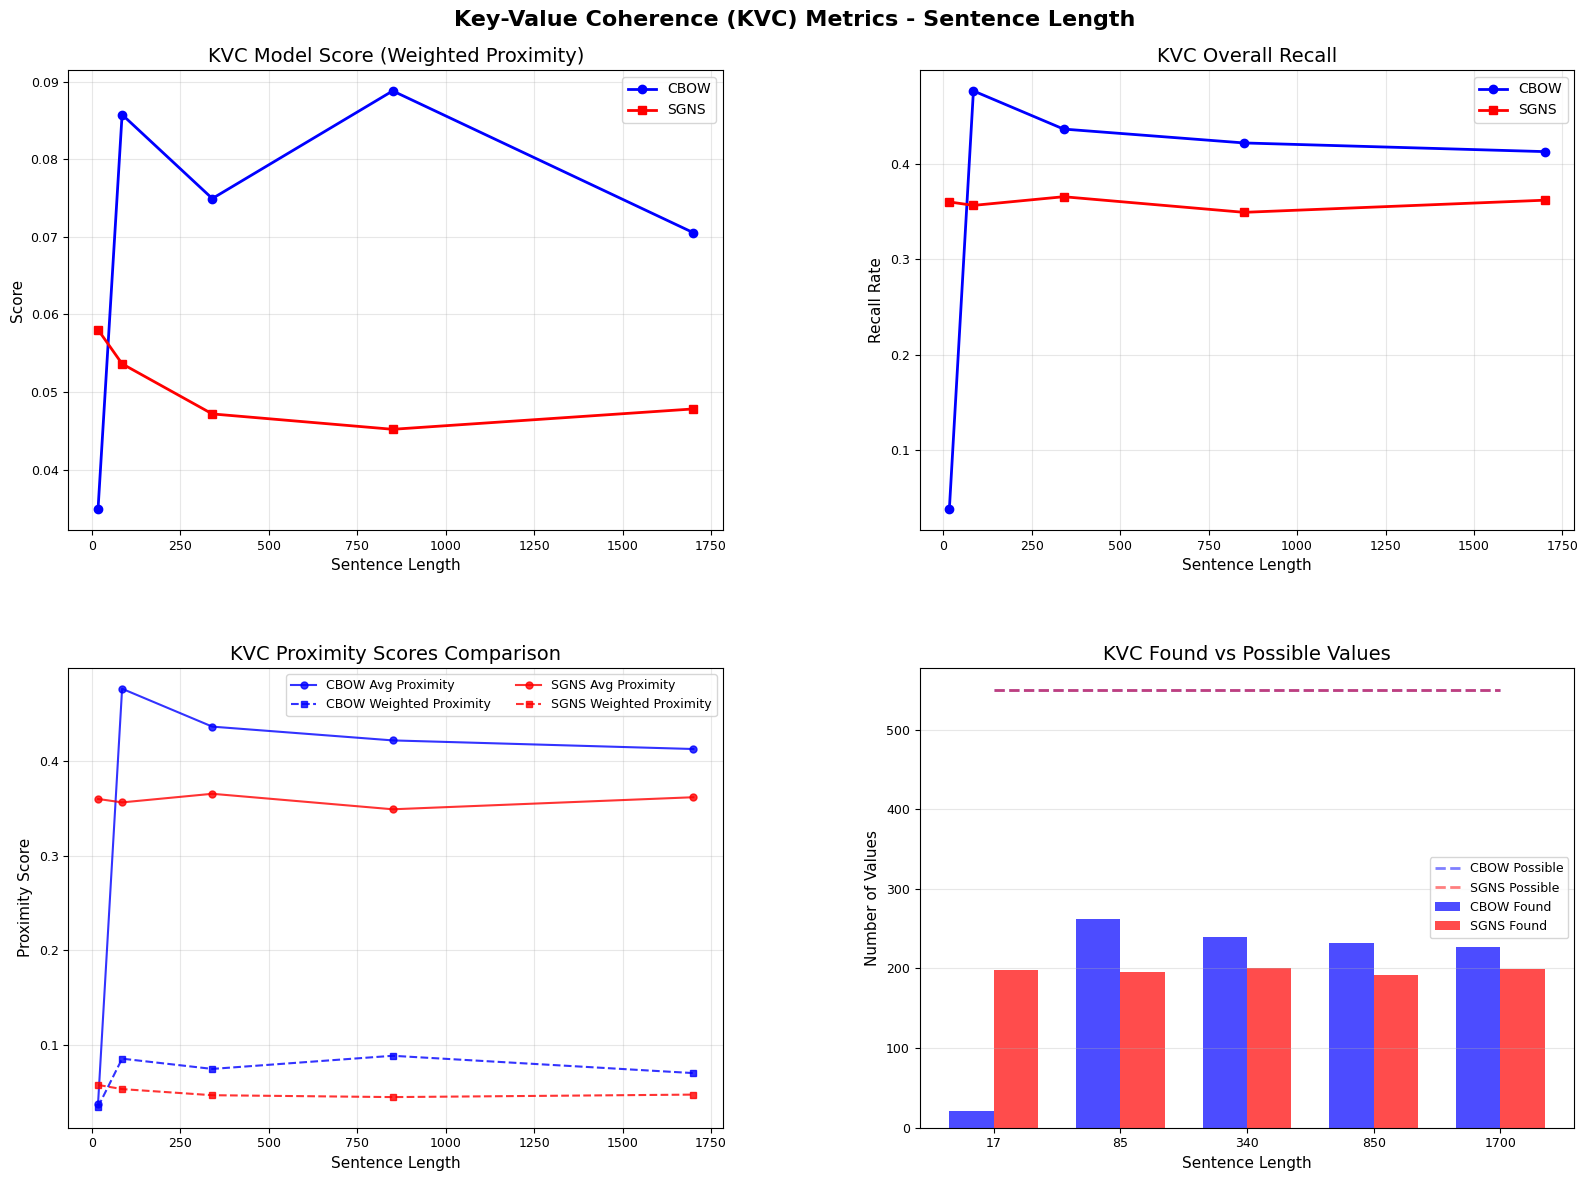


KVC METRICS SUMMARY FOR CATEGORY: SENTENCE

KVC PERFORMANCE METRICS:
------------------------------------------------------------------------------------------------------------------------
Sentence Length CBOW KVC:                                SGNS KVC:                               
                Model      Avg Prox   Wtd Prox   Recall     Model      Avg Prox   Wtd Prox   Recall    
------------------------------------------------------------------------------------------------------------------------
17              0.0349     0.0382     0.0349     0.0382     0.058      0.36       0.058      0.36      
85              0.0858     0.4764     0.0858     0.4764     0.0536     0.3564     0.0536     0.3564    
340             0.0749     0.4364     0.0749     0.4364     0.0472     0.3655     0.0472     0.3655    
850             0.0888     0.4218     0.0888     0.4218     0.0452     0.3491     0.0452     0.3491    
1700            0.0705     0.4127     0.0705     0.4127     0.0478    

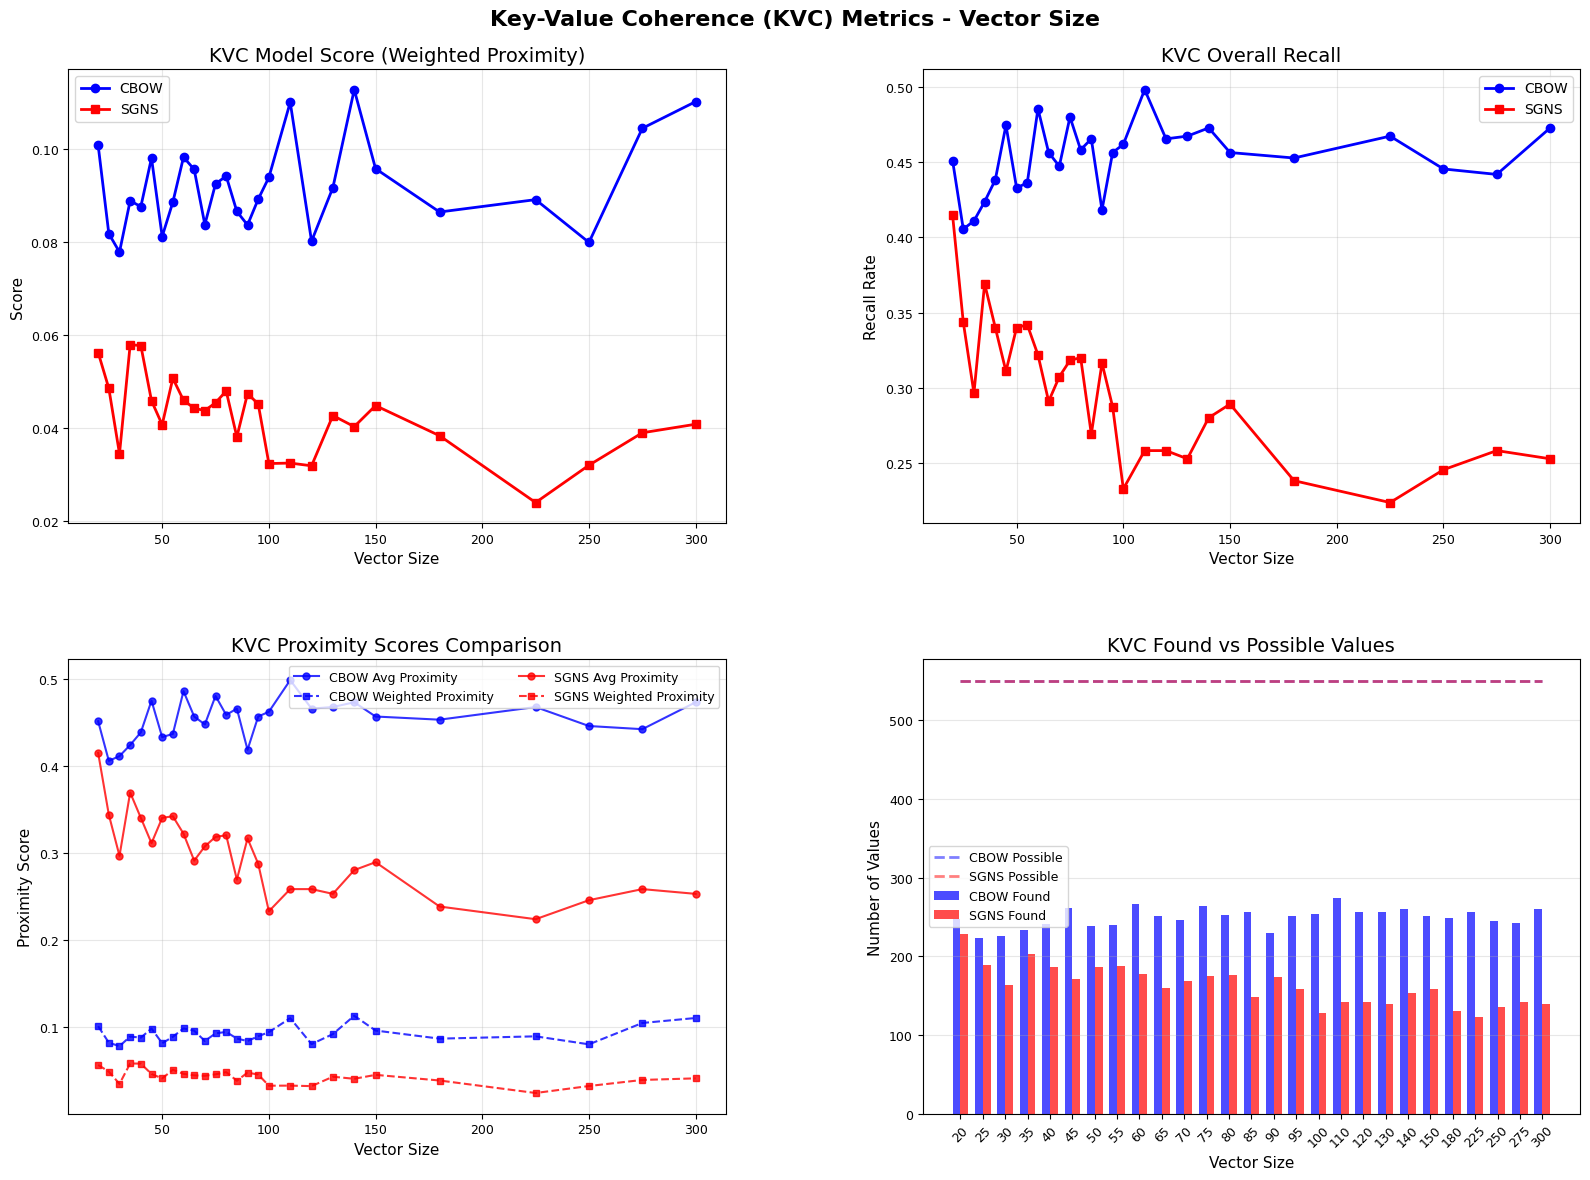


KVC METRICS SUMMARY FOR CATEGORY: VECTOR

KVC PERFORMANCE METRICS:
------------------------------------------------------------------------------------------------------------------------
Vector Size     CBOW KVC:                                SGNS KVC:                               
                Model      Avg Prox   Wtd Prox   Recall     Model      Avg Prox   Wtd Prox   Recall    
------------------------------------------------------------------------------------------------------------------------
20              0.1008     0.4509     0.1008     0.4509     0.0563     0.4145     0.0563     0.4145    
25              0.0818     0.4055     0.0818     0.4055     0.0486     0.3436     0.0486     0.3436    
30              0.0779     0.4109     0.0779     0.4109     0.0345     0.2964     0.0345     0.2964    
35              0.0889     0.4236     0.0889     0.4236     0.058      0.3691     0.058      0.3691    
40              0.0876     0.4382     0.0876     0.4382     0.0578     0

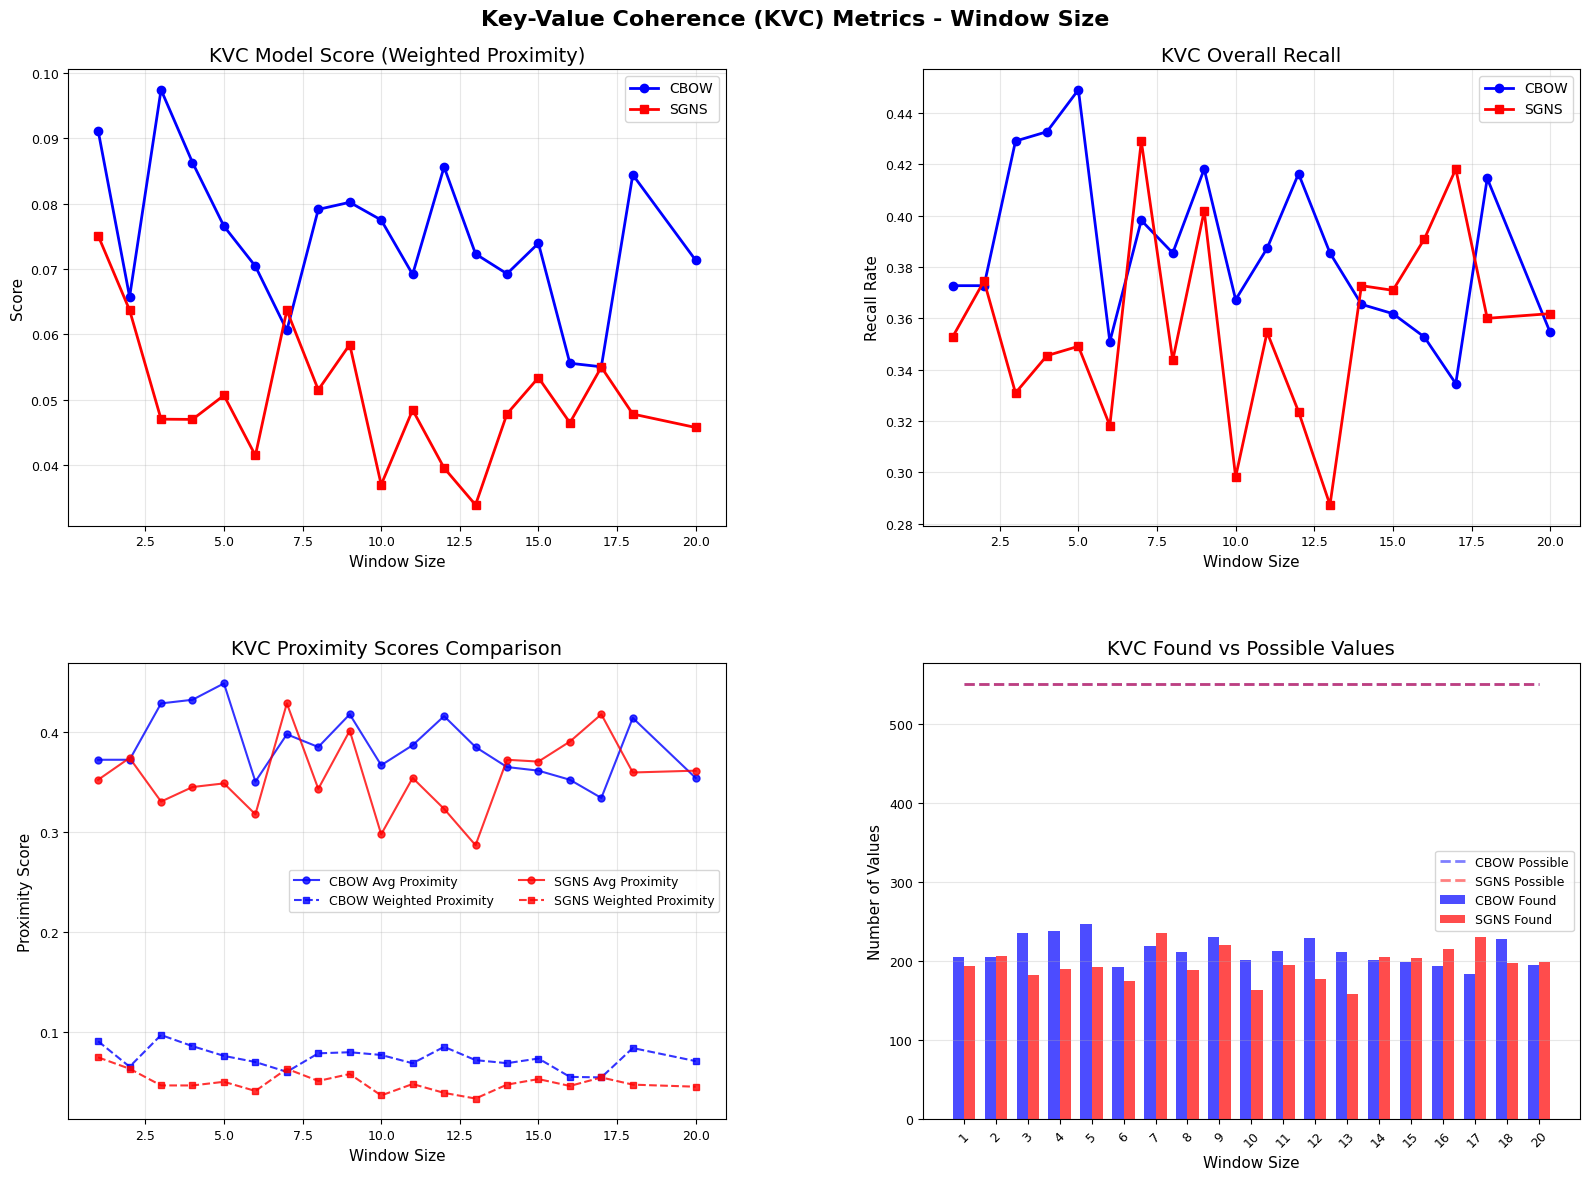


KVC METRICS SUMMARY FOR CATEGORY: WINDOWSIZE

KVC PERFORMANCE METRICS:
------------------------------------------------------------------------------------------------------------------------
Window Size     CBOW KVC:                                SGNS KVC:                               
                Model      Avg Prox   Wtd Prox   Recall     Model      Avg Prox   Wtd Prox   Recall    
------------------------------------------------------------------------------------------------------------------------
1               0.0912     0.3727     0.0912     0.3727     0.0751     0.3527     0.0751     0.3527    
2               0.0657     0.3727     0.0657     0.3727     0.0637     0.3745     0.0637     0.3745    
3               0.0974     0.4291     0.0974     0.4291     0.047      0.3309     0.047      0.3309    
4               0.0863     0.4327     0.0863     0.4327     0.047      0.3455     0.047      0.3455    
5               0.0766     0.4491     0.0766     0.4491     0.0507  

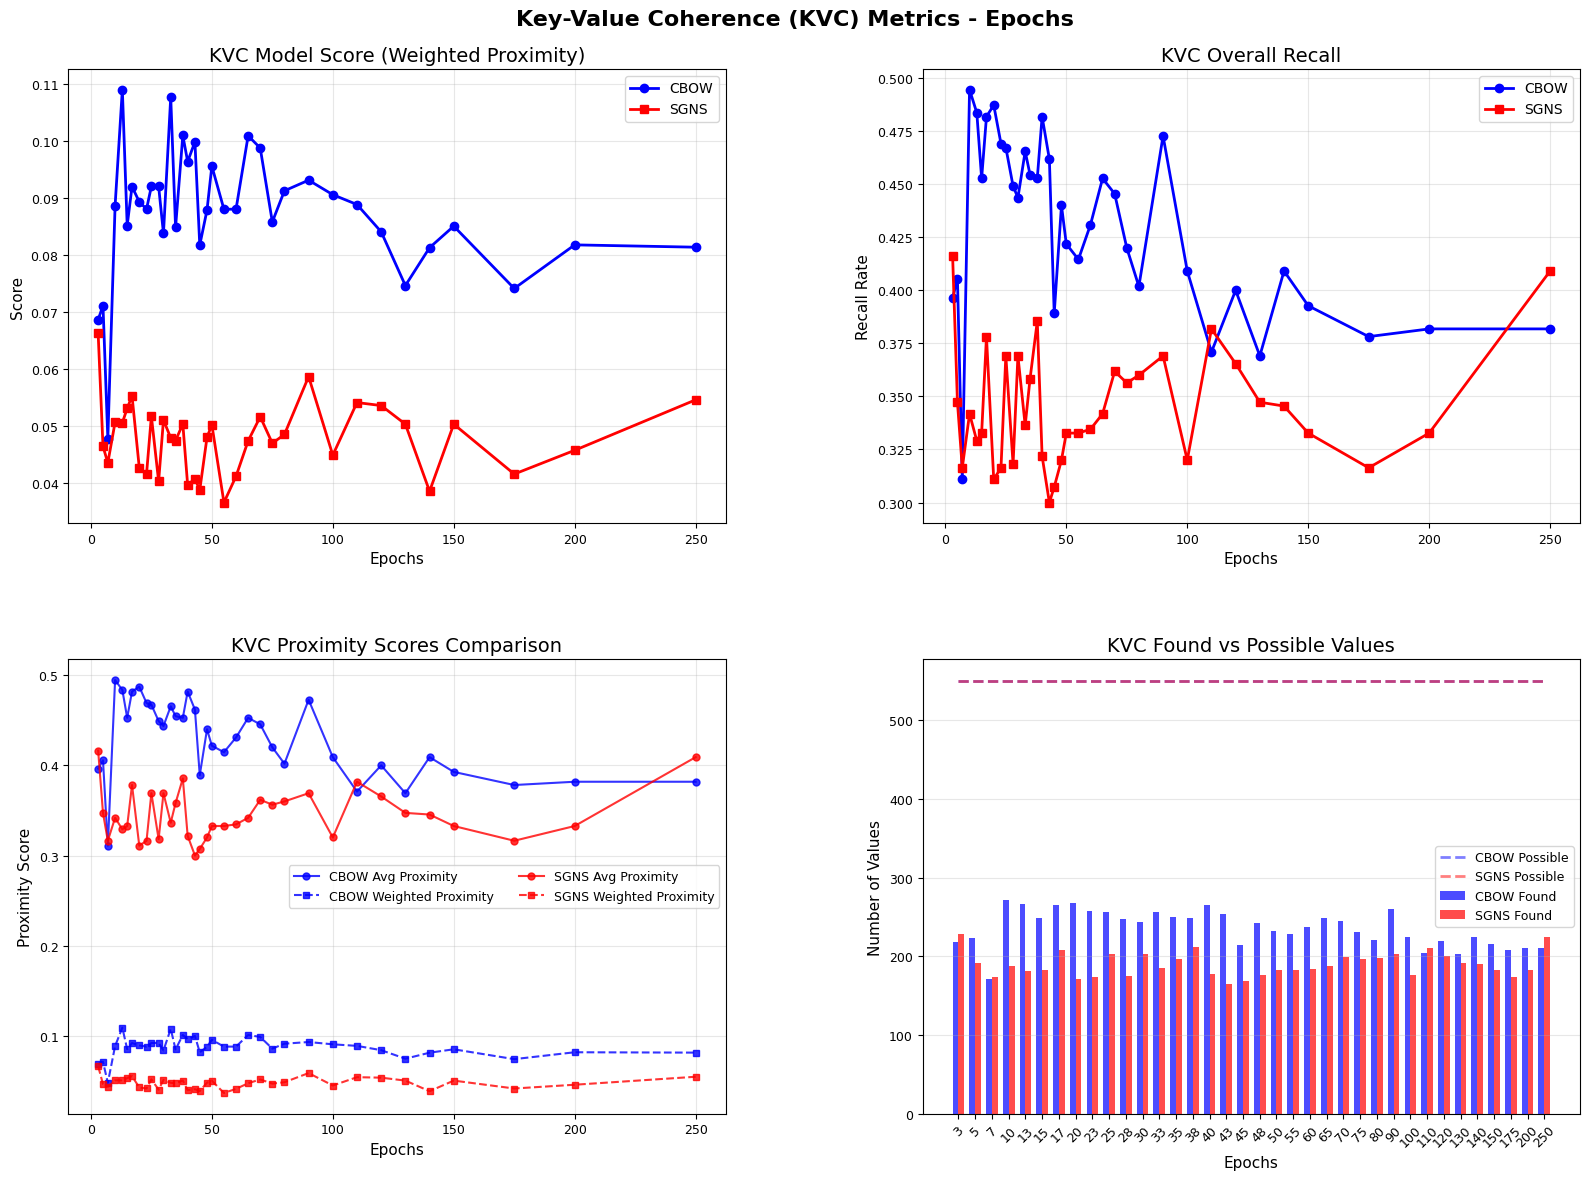


KVC METRICS SUMMARY FOR CATEGORY: EPOCH

KVC PERFORMANCE METRICS:
------------------------------------------------------------------------------------------------------------------------
Epochs          CBOW KVC:                                SGNS KVC:                               
                Model      Avg Prox   Wtd Prox   Recall     Model      Avg Prox   Wtd Prox   Recall    
------------------------------------------------------------------------------------------------------------------------
3               0.0687     0.3964     0.0687     0.3964     0.0663     0.4164     0.0663     0.4164    
5               0.0712     0.4055     0.0712     0.4055     0.0465     0.3473     0.0465     0.3473    
7               0.0478     0.3109     0.0478     0.3109     0.0436     0.3164     0.0436     0.3164    
10              0.0887     0.4945     0.0887     0.4945     0.0507     0.3418     0.0507     0.3418    
13              0.109      0.4836     0.109      0.4836     0.0506     0.

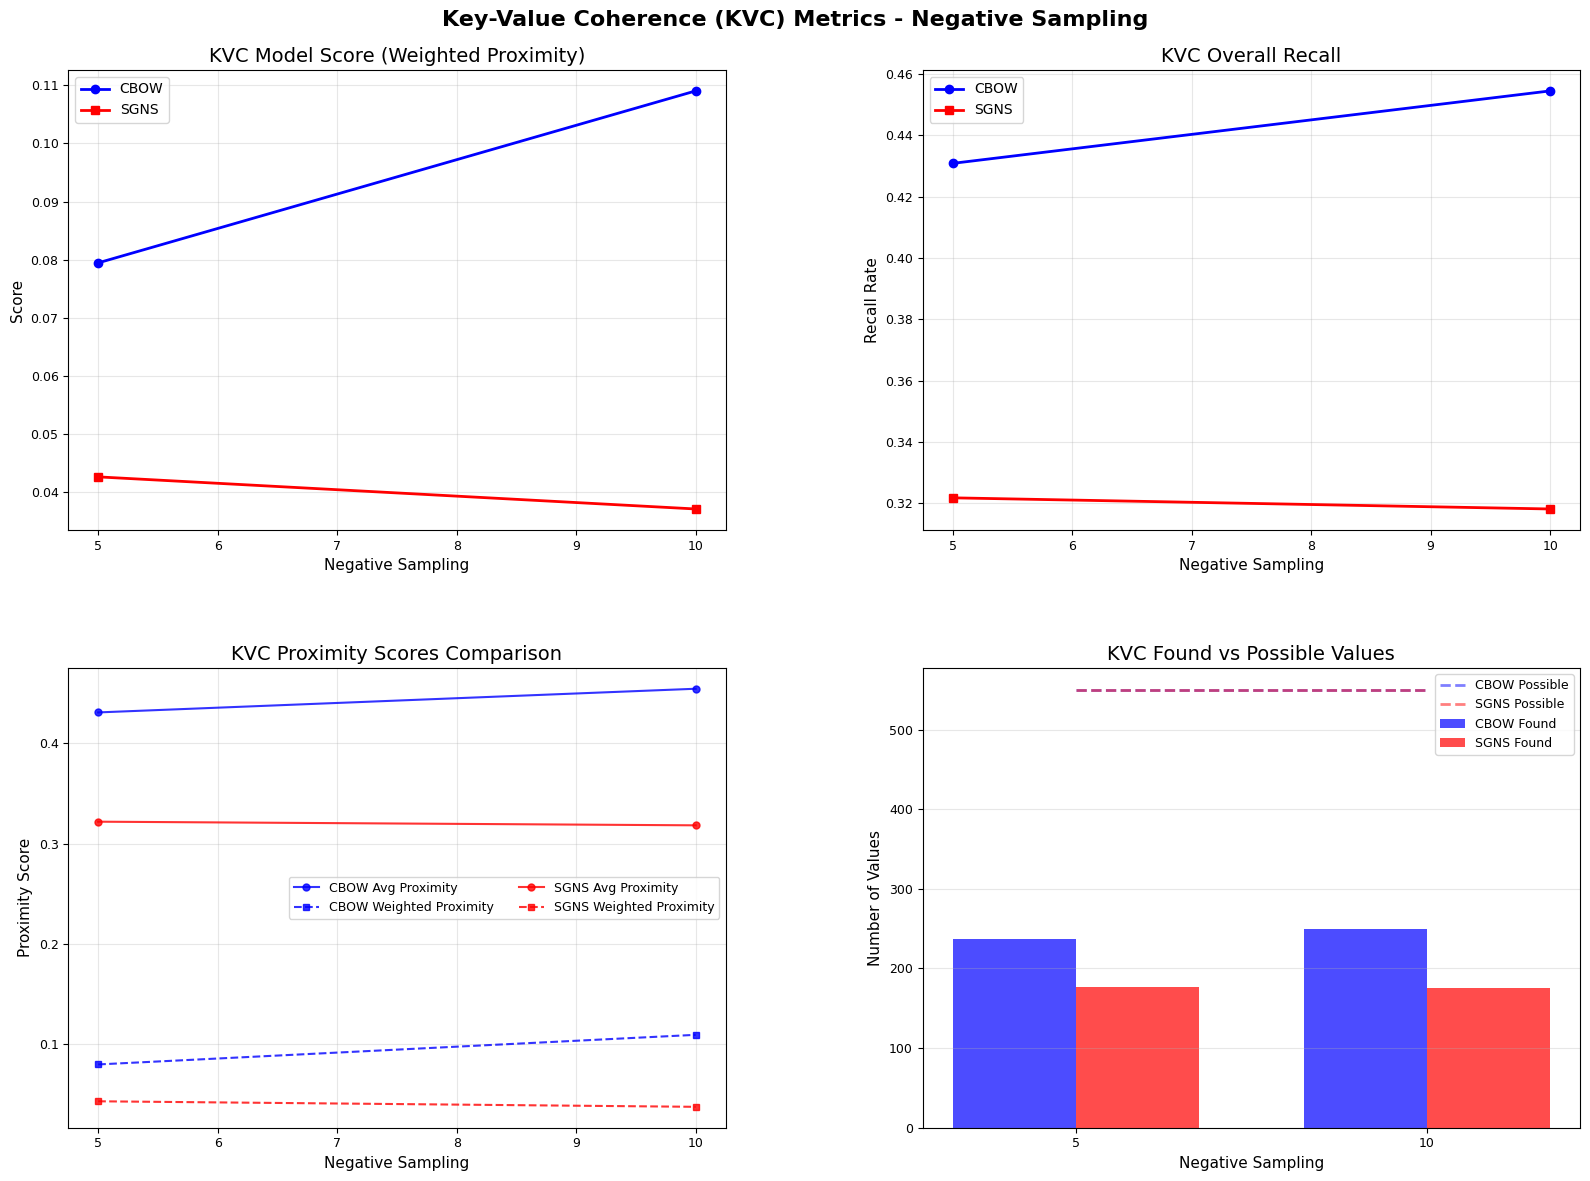


KVC METRICS SUMMARY FOR CATEGORY: NEGATIVE

KVC PERFORMANCE METRICS:
------------------------------------------------------------------------------------------------------------------------
Negative Sampling CBOW KVC:                                SGNS KVC:                               
                Model      Avg Prox   Wtd Prox   Recall     Model      Avg Prox   Wtd Prox   Recall    
------------------------------------------------------------------------------------------------------------------------
5               0.0795     0.4309     0.0795     0.4309     0.0427     0.3218     0.0427     0.3218    
10              0.109      0.4545     0.109      0.4545     0.0371     0.3182     0.0371     0.3182    

KVC VALUE COUNTS:
--------------------------------------------------------------------------------
Negative Sampling CBOW:                     SGNS:                    
                Found      Possible   Keys       Found      Possible   Keys      
------------------------

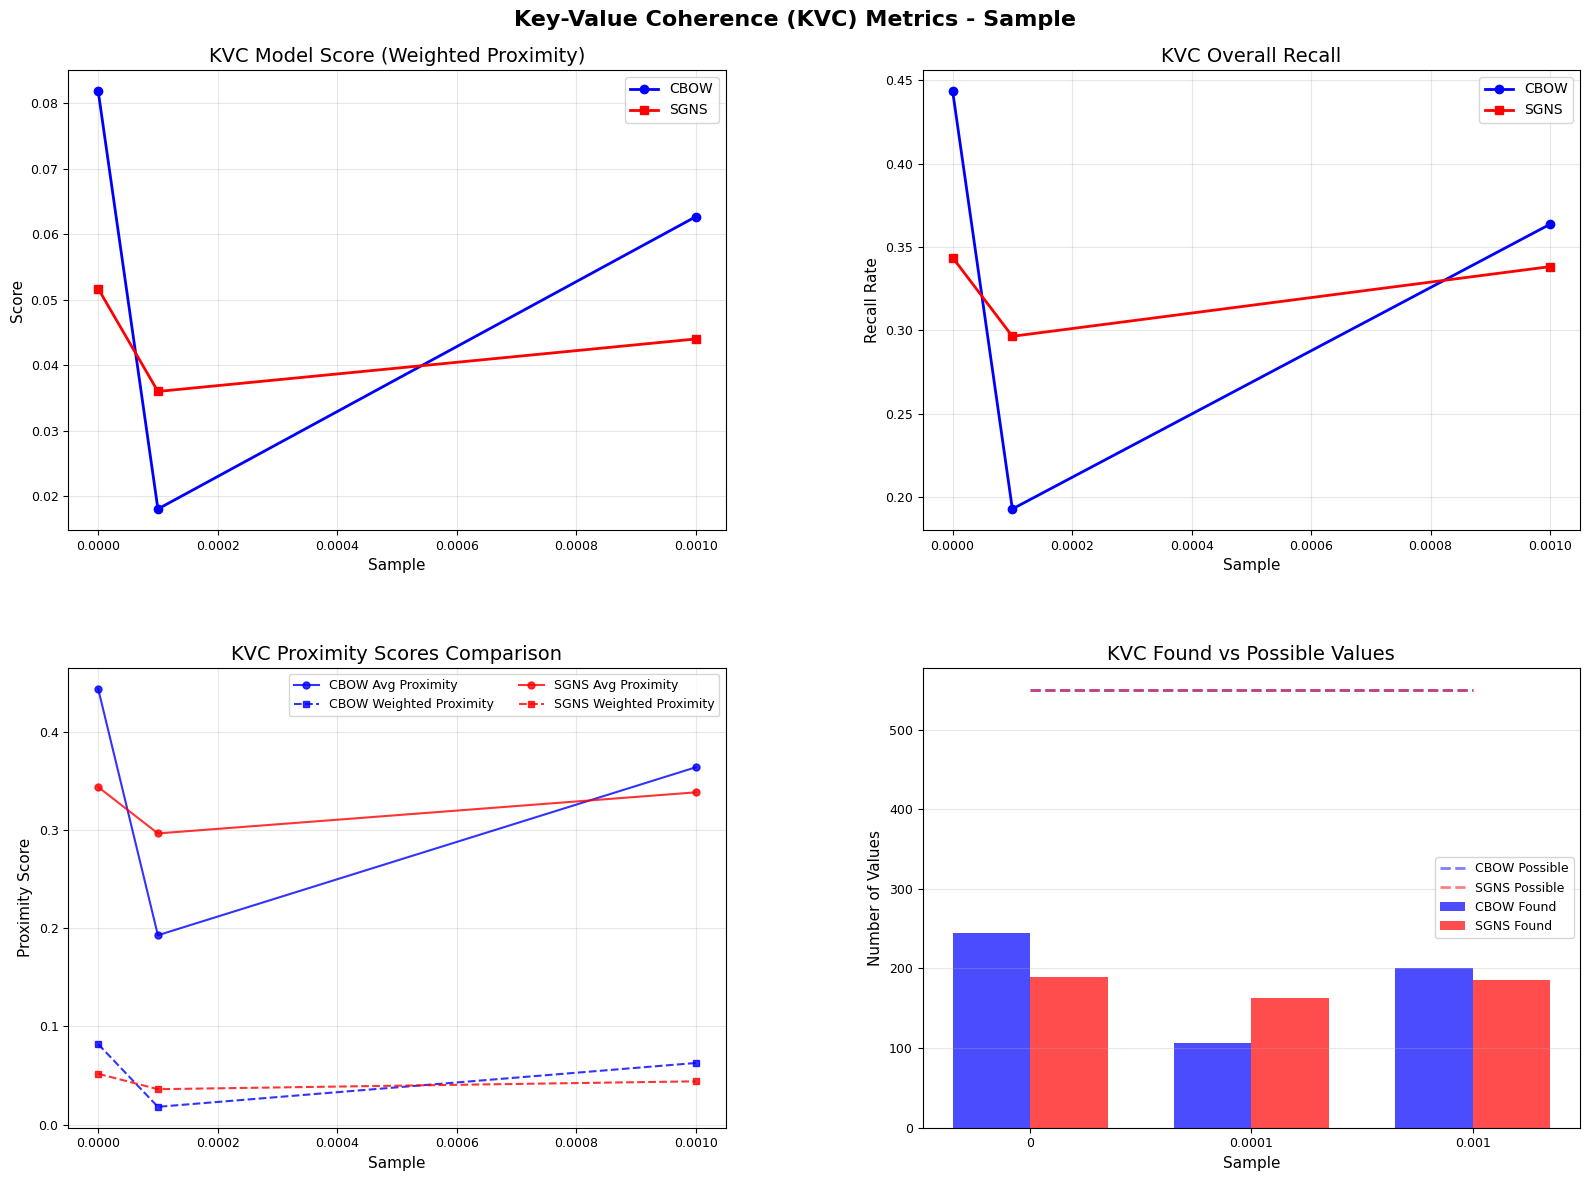


KVC METRICS SUMMARY FOR CATEGORY: SAMPLE

KVC PERFORMANCE METRICS:
------------------------------------------------------------------------------------------------------------------------
Sample          CBOW KVC:                                SGNS KVC:                               
                Model      Avg Prox   Wtd Prox   Recall     Model      Avg Prox   Wtd Prox   Recall    
------------------------------------------------------------------------------------------------------------------------
0               0.0819     0.4436     0.0819     0.4436     0.0517     0.3436     0.0517     0.3436    
0.0001          0.0181     0.1927     0.0181     0.1927     0.036      0.2964     0.036      0.2964    
0.001           0.0627     0.3636     0.0627     0.3636     0.044      0.3382     0.044      0.3382    

KVC VALUE COUNTS:
--------------------------------------------------------------------------------
Sample          CBOW:                     SGNS:                    
        

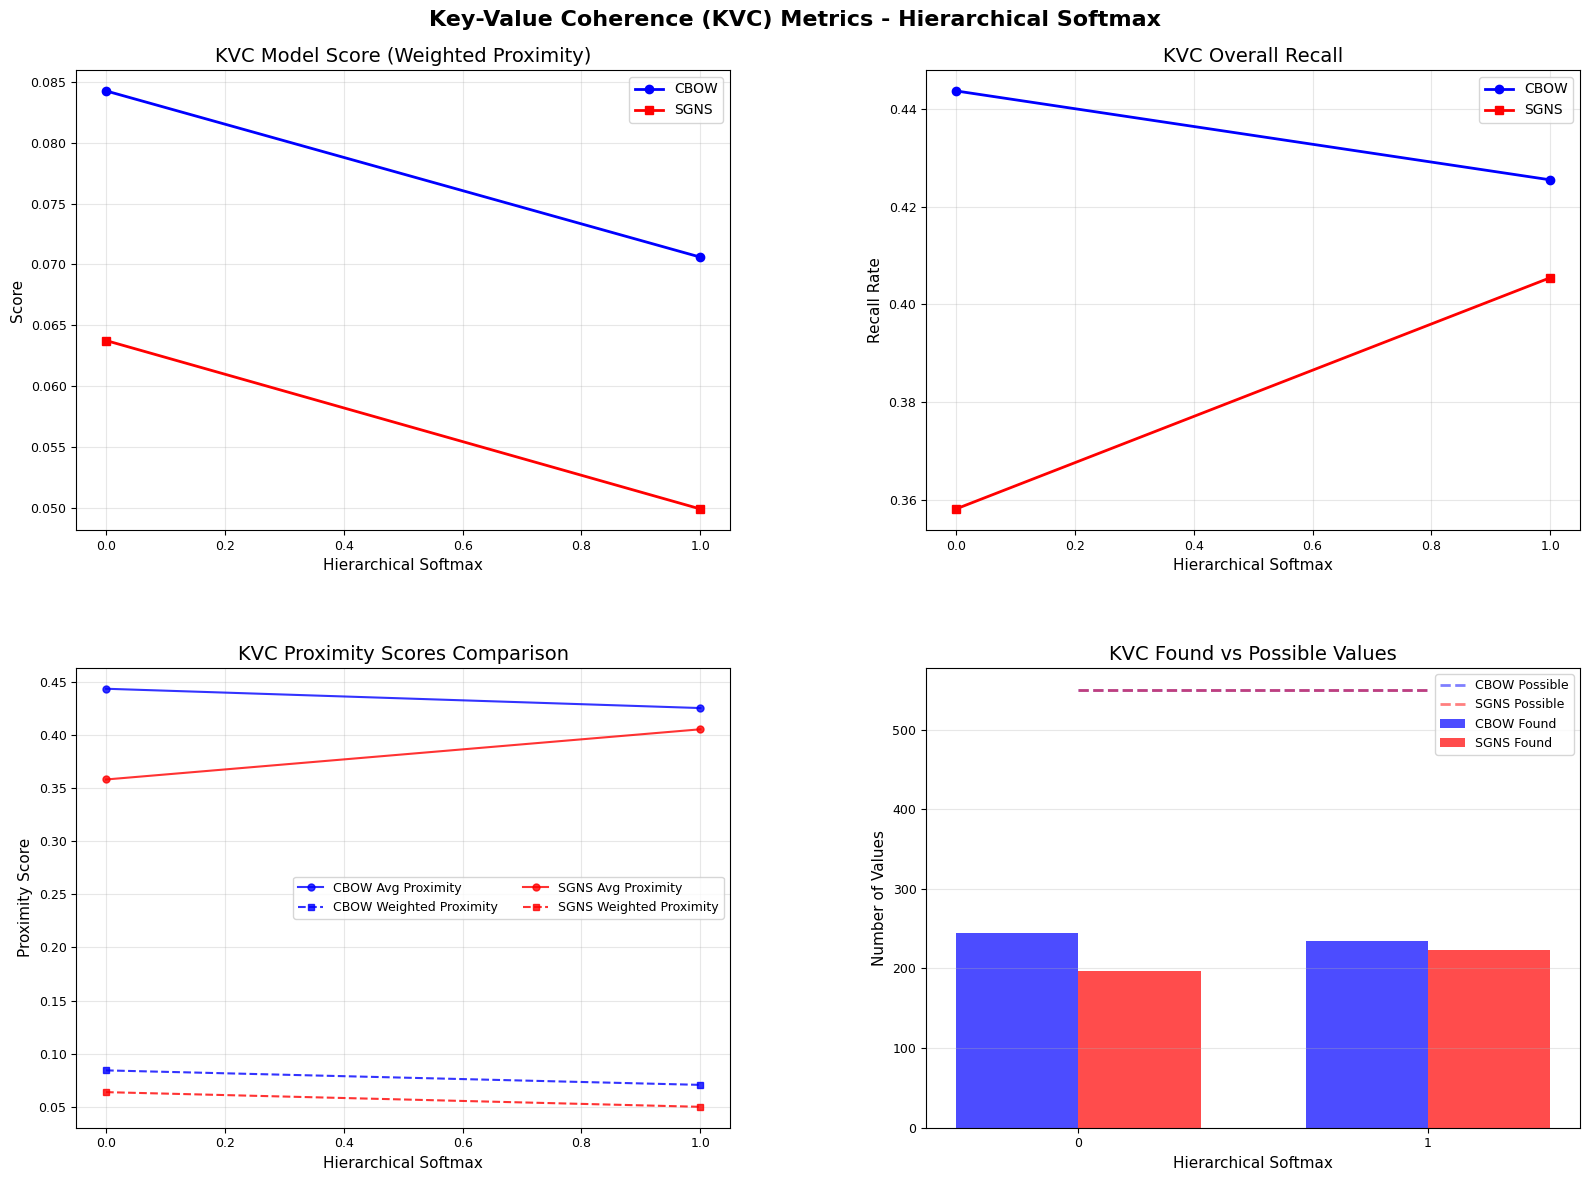


KVC METRICS SUMMARY FOR CATEGORY: HS

KVC PERFORMANCE METRICS:
------------------------------------------------------------------------------------------------------------------------
Hierarchical Softmax CBOW KVC:                                SGNS KVC:                               
                Model      Avg Prox   Wtd Prox   Recall     Model      Avg Prox   Wtd Prox   Recall    
------------------------------------------------------------------------------------------------------------------------
0               0.0842     0.4436     0.0842     0.4436     0.0638     0.3582     0.0638     0.3582    
1               0.0706     0.4255     0.0706     0.4255     0.0499     0.4055     0.0499     0.4055    

KVC VALUE COUNTS:
--------------------------------------------------------------------------------
Hierarchical Softmax CBOW:                     SGNS:                    
                Found      Possible   Keys       Found      Possible   Keys      
------------------------

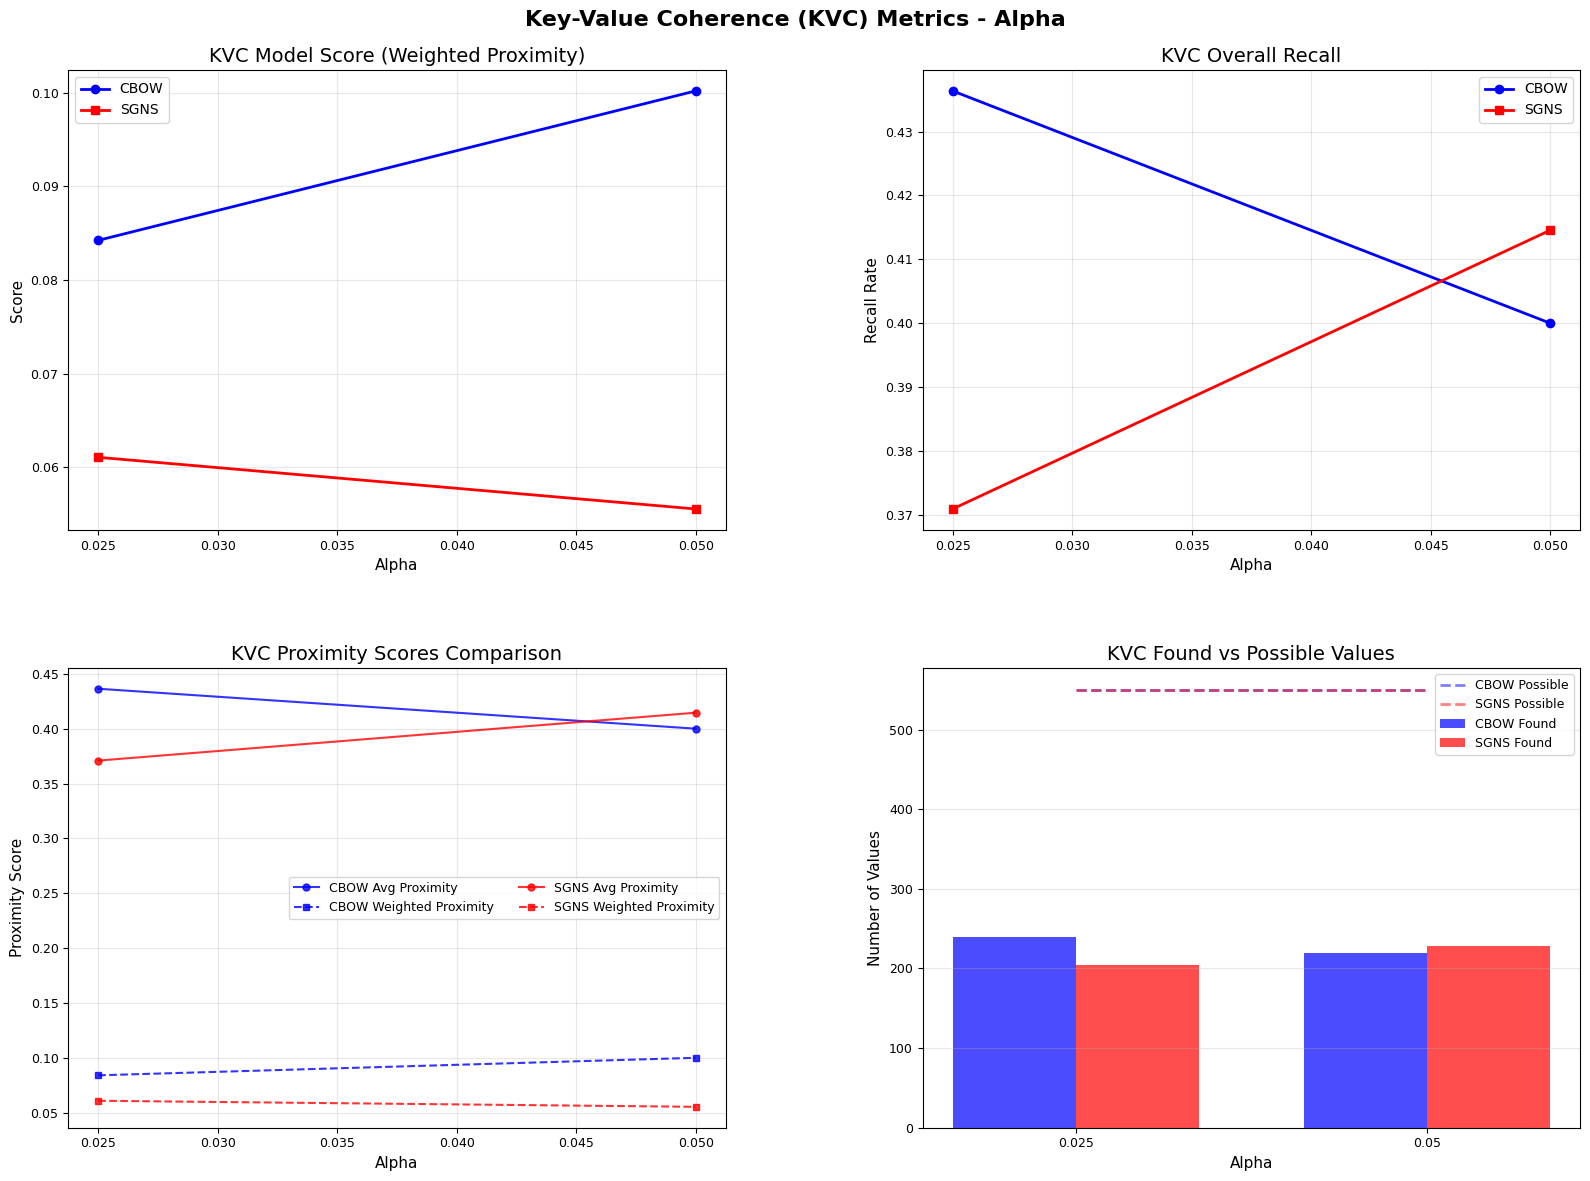


KVC METRICS SUMMARY FOR CATEGORY: ALPHA

KVC PERFORMANCE METRICS:
------------------------------------------------------------------------------------------------------------------------
Alpha           CBOW KVC:                                SGNS KVC:                               
                Model      Avg Prox   Wtd Prox   Recall     Model      Avg Prox   Wtd Prox   Recall    
------------------------------------------------------------------------------------------------------------------------
0.025           0.0842     0.4364     0.0842     0.4364     0.0611     0.3709     0.0611     0.3709    
0.05            0.1002     0.4        0.1002     0.4        0.0556     0.4145     0.0556     0.4145    

KVC VALUE COUNTS:
--------------------------------------------------------------------------------
Alpha           CBOW:                     SGNS:                    
                Found      Possible   Keys       Found      Possible   Keys      
-------------------------------

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Daten nach Kategorien und Algorithmen strukturieren
data_by_category = {}

for result in test_results:
    category = result['params']['Test_Category']
    algorithm = result['params']['Algorithmus']
    
    if category not in data_by_category:
        # Erweiterte Datenstruktur für alle Metriken inklusive KVC
        data_by_category[category] = {
            'CBOW': {
                # Hauptmetriken
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {},
                # KVC Metriken
                'kvc_model_score': {}, 'kvc_avg_proximity': {}, 'kvc_weighted_proximity': {},
                'kvc_recall': {}, 'kvc_found_values': {}, 'kvc_possible_values': {},
                'kvc_keys_evaluated': {}
            },
            'SGNS': {
                # Hauptmetriken
                'nd': {}, 'rs_mean': {}, 'rs_5': {}, 'rs_10': {}, 'rs_20': {},
                'fc': {}, 'ssmq': {},
                # KVC Metriken
                'kvc_model_score': {}, 'kvc_avg_proximity': {}, 'kvc_weighted_proximity': {},
                'kvc_recall': {}, 'kvc_found_values': {}, 'kvc_possible_values': {},
                'kvc_keys_evaluated': {}
            }
        }
    
    # Determine which parameter is relevant for this category
    if category == 'sentence':
        x_value = result['params']['Satzlänge']
        x_label = 'Sentence Length'
        title_category = 'Sentence Length'
    elif category == 'vector':
        x_value = result['params']['Vector Size']
        x_label = 'Vector Size'
        title_category = 'Vector Size'
    elif category == 'windowsize':
        x_value = result['params']['Window']
        x_label = 'Window Size'
        title_category = 'Window Size'
    elif category == 'epoch':
        x_value = result['params']['Epochs']
        x_label = 'Epochs'
        title_category = 'Epochs'
    elif category == 'negative':
        x_value = result['params']['Negative Sampling']
        x_label = 'Negative Sampling'
        title_category = 'Negative Sampling'
    elif category == 'sample':
        x_value = result['params']['Sample']
        x_label = 'Sample'
        title_category = 'Sample'
    elif category == 'hs':
        x_value = result['params']['Hierarchical Softmax']
        x_label = 'Hierarchical Softmax'
        title_category = 'Hierarchical Softmax'
    elif category == 'alpha':
        x_value = result['params']['Alpha']
        x_label = 'Alpha'
        title_category = 'Alpha'
    else:
        x_value = None
        x_label = 'UNKNOWN - PLEASE SET'
        title_category = category
        print(f"Unknown category: {category}")
    
    # Extract all metrics if they exist
    nd_value = None
    if 'nd' in result:
        if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
            nd_value = float(result['nd'][0])
        else:
            nd_value = float(result['nd'])
    
    # Extract other main metrics
    rs_mean_value = float(result['rs_mean']) if 'rs_mean' in result else None
    rs_5_value = float(result['rs_5']) if 'rs_5' in result else None
    rs_10_value = float(result['rs_10']) if 'rs_10' in result else None
    rs_20_value = float(result['rs_20']) if 'rs_20' in result else None
    fc_value = float(result['fc']) if 'fc' in result else None
    ssmq_value = float(result['ssmq']) if 'ssmq' in result else None
    
    # Extract KVC metrics if they exist
    kvc_model_score = None
    kvc_avg_proximity = None
    kvc_weighted_proximity = None
    kvc_recall = None
    kvc_found_values = None
    kvc_possible_values = None
    kvc_keys_evaluated = None
    
    if 'kvc' in result:
        kvc_data = result['kvc']
        kvc_model_score = float(kvc_data.get('model_score', 0))
        kvc_avg_proximity = float(kvc_data.get('avg_proximity_score', 0))
        kvc_weighted_proximity = float(kvc_data.get('avg_weighted_proximity_score', 0))
        
        # Calculate recall if not directly available
        if 'overall_recall' in kvc_data:
            kvc_recall = float(kvc_data['overall_recall'])
        elif 'total_found_values' in kvc_data and 'total_possible_values' in kvc_data:
            total_found = kvc_data['total_found_values']
            total_possible = kvc_data['total_possible_values']
            kvc_recall = total_found / total_possible if total_possible > 0 else 0
        
        kvc_found_values = kvc_data.get('total_found_values', 0)
        kvc_possible_values = kvc_data.get('total_possible_values', 0)
        kvc_keys_evaluated = kvc_data.get('keys_evaluated', 0)
    
    if x_value is not None:
        # Store all available metrics
        main_metrics = [
            ('nd', nd_value),
            ('rs_mean', rs_mean_value),
            ('rs_5', rs_5_value),
            ('rs_10', rs_10_value),
            ('rs_20', rs_20_value),
            ('fc', fc_value),
            ('ssmq', ssmq_value)
        ]
        
        kvc_metrics = [
            ('kvc_model_score', kvc_model_score),
            ('kvc_avg_proximity', kvc_avg_proximity),
            ('kvc_weighted_proximity', kvc_weighted_proximity),
            ('kvc_recall', kvc_recall),
            ('kvc_found_values', kvc_found_values),
            ('kvc_possible_values', kvc_possible_values),
            ('kvc_keys_evaluated', kvc_keys_evaluated)
        ]
        
        # Store main metrics
        for metric_name, metric_value in main_metrics:
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value
        
        # Store KVC metrics
        for metric_name, metric_value in kvc_metrics:
            if metric_value is not None:
                data_by_category[category][algorithm][metric_name][x_value] = metric_value

# OPTION 1: Separate KVC Plots (empfohlen für Detailanalyse)
print("=== SEPARATE KVC METRICS VISUALIZATION ===")
for category, category_data in data_by_category.items():
    # Get the correct labels for this category
    if category == 'sentence':
        x_label = 'Sentence Length'
        title_category = 'Sentence Length'
    elif category == 'vector':
        x_label = 'Vector Size'
        title_category = 'Vector Size'
    elif category == 'windowsize':
        x_label = 'Window Size'
        title_category = 'Window Size'
    elif category == 'epoch':
        x_label = 'Epochs'
        title_category = 'Epochs'
    elif category == 'negative':
        x_label = 'Negative Sampling'
        title_category = 'Negative Sampling'
    elif category == 'sample':
        x_label = 'Sample'
        title_category = 'Sample'
    elif category == 'hs':
        x_label = 'Hierarchical Softmax'
        title_category = 'Hierarchical Softmax'
    elif category == 'alpha':
        x_label = 'Alpha'
        title_category = 'Alpha'
    else:
        x_label = 'X-Axis'
        title_category = category
    
    # Create figure for KVC metrics (2x2 grid)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Key-Value Coherence (KVC) Metrics - {title_category}', fontsize=16, fontweight='bold')
    
    axs = axes.flatten()
    
    # 1. KVC Model Score (Top Left)
    ax1 = axs[0]
    cbow_model_score = category_data['CBOW']['kvc_model_score']
    sgns_model_score = category_data['SGNS']['kvc_model_score']
    
    if cbow_model_score or sgns_model_score:
        if cbow_model_score:
            x_cbow = sorted(cbow_model_score.keys())
            y_cbow = [cbow_model_score[x] for x in x_cbow]
            ax1.plot(x_cbow, y_cbow, 'b-o', linewidth=2, markersize=6, label='CBOW')
        
        if sgns_model_score:
            x_sgns = sorted(sgns_model_score.keys())
            y_sgns = [sgns_model_score[x] for x in x_sgns]
            ax1.plot(x_sgns, y_sgns, 'r-s', linewidth=2, markersize=6, label='SGNS')
        
        ax1.set_title('KVC Model Score (Weighted Proximity)', fontsize=14)
        ax1.set_xlabel(x_label, fontsize=11)
        ax1.set_ylabel('Score', fontsize=11)
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)
    else:
        ax1.text(0.5, 0.5, 'No KVC Model Score data', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax1.transAxes, fontsize=12)
        ax1.set_title('KVC Model Score', fontsize=14)
    
    # 2. KVC Recall (Top Right)
    ax2 = axs[1]
    cbow_recall = category_data['CBOW']['kvc_recall']
    sgns_recall = category_data['SGNS']['kvc_recall']
    
    if cbow_recall or sgns_recall:
        if cbow_recall:
            x_cbow = sorted(cbow_recall.keys())
            y_cbow = [cbow_recall[x] for x in x_cbow]
            ax2.plot(x_cbow, y_cbow, 'b-o', linewidth=2, markersize=6, label='CBOW')
        
        if sgns_recall:
            x_sgns = sorted(sgns_recall.keys())
            y_sgns = [sgns_recall[x] for x in x_sgns]
            ax2.plot(x_sgns, y_sgns, 'r-s', linewidth=2, markersize=6, label='SGNS')
        
        ax2.set_title('KVC Overall Recall', fontsize=14)
        ax2.set_xlabel(x_label, fontsize=11)
        ax2.set_ylabel('Recall Rate', fontsize=11)
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'No KVC Recall data', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax2.transAxes, fontsize=12)
        ax2.set_title('KVC Recall', fontsize=14)
    
    # 3. KVC Proximity Scores Comparison (Bottom Left)
    ax3 = axs[2]
    
    # Define KVC metrics to plot
    kvc_proximity_metrics = [
        ('kvc_avg_proximity', 'Avg Proximity', '-', 'o'),
        ('kvc_weighted_proximity', 'Weighted Proximity', '--', 's')
    ]
    
    # Plot CBOW KVC proximity metrics
    for kvc_key, kvc_label, linestyle, marker in kvc_proximity_metrics:
        cbow_data = category_data['CBOW'][kvc_key]
        if cbow_data:
            x_cbow = sorted(cbow_data.keys())
            y_cbow = [cbow_data[x] for x in x_cbow]
            ax3.plot(x_cbow, y_cbow, f'b{marker}{linestyle}', linewidth=1.5, markersize=5, 
                    label=f'CBOW {kvc_label}', alpha=0.8)
    
    # Plot SGNS KVC proximity metrics
    for kvc_key, kvc_label, linestyle, marker in kvc_proximity_metrics:
        sgns_data = category_data['SGNS'][kvc_key]
        if sgns_data:
            x_sgns = sorted(sgns_data.keys())
            y_sgns = [sgns_data[x] for x in x_sgns]
            ax3.plot(x_sgns, y_sgns, f'r{marker}{linestyle}', linewidth=1.5, markersize=5, 
                    label=f'SGNS {kvc_label}', alpha=0.8)
    
    ax3.set_title('KVC Proximity Scores Comparison', fontsize=14)
    ax3.set_xlabel(x_label, fontsize=11)
    ax3.set_ylabel('Proximity Score', fontsize=11)
    ax3.legend(fontsize=9, ncol=2)
    ax3.grid(True, alpha=0.3)
    
    # 4. KVC Found vs Possible Values (Bottom Right)
    ax4 = axs[3]
    
    # Prepare data for bar chart
    x_values = sorted(set(list(category_data['CBOW']['kvc_found_values'].keys()) + 
                          list(category_data['SGNS']['kvc_found_values'].keys())))
    
    if x_values:
        # Get data for bar chart
        cbow_found = [category_data['CBOW']['kvc_found_values'].get(x, 0) for x in x_values]
        sgns_found = [category_data['SGNS']['kvc_found_values'].get(x, 0) for x in x_values]
        cbow_possible = [category_data['CBOW']['kvc_possible_values'].get(x, 0) for x in x_values]
        sgns_possible = [category_data['SGNS']['kvc_possible_values'].get(x, 0) for x in x_values]
        
        x_pos = np.arange(len(x_values))
        width = 0.35
        
        # Create grouped bar chart
        bars1 = ax4.bar(x_pos - width/2, cbow_found, width, label='CBOW Found', color='blue', alpha=0.7)
        bars2 = ax4.bar(x_pos + width/2, sgns_found, width, label='SGNS Found', color='red', alpha=0.7)
        
        # Add possible values as line
        ax4.plot(x_pos, cbow_possible, 'b--', linewidth=2, label='CBOW Possible', alpha=0.5)
        ax4.plot(x_pos, sgns_possible, 'r--', linewidth=2, label='SGNS Possible', alpha=0.5)
        
        ax4.set_title('KVC Found vs Possible Values', fontsize=14)
        ax4.set_xlabel(x_label, fontsize=11)
        ax4.set_ylabel('Number of Values', fontsize=11)
        ax4.set_xticks(x_pos)
        ax4.set_xticklabels(x_values, rotation=45 if len(x_values) > 5 else 0)
        ax4.legend(fontsize=9)
        ax4.grid(True, alpha=0.3, axis='y')
    else:
        ax4.text(0.5, 0.5, 'No KVC Values data', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax4.transAxes, fontsize=12)
        ax4.set_title('KVC Found vs Possible Values', fontsize=14)
    
    # Better readability for all subplots
    for ax in axs:
        ax.tick_params(axis='x', labelsize=9)
        ax.tick_params(axis='y', labelsize=9)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, hspace=0.3, wspace=0.3)
    plt.show()
    
    # Tabular overview for KVC metrics
    print(f"\n{'='*100}")
    print(f"KVC METRICS SUMMARY FOR CATEGORY: {category.upper()}")
    print(f"{'='*100}")
    
    # Find common x-values
    all_x = set()
    for algorithm in ['CBOW', 'SGNS']:
        for metric in ['kvc_model_score', 'kvc_avg_proximity', 'kvc_weighted_proximity', 
                      'kvc_recall', 'kvc_found_values', 'kvc_possible_values']:
            all_x.update(category_data[algorithm][metric].keys())
    
    sorted_x = sorted(all_x)
    
    if sorted_x:
        print(f"\nKVC PERFORMANCE METRICS:")
        print("-" * 120)
        print(f"{x_label:<15} {'CBOW KVC:':<40} {'SGNS KVC:':<40}")
        print(f"{'':<15} {'Model':<10} {'Avg Prox':<10} {'Wtd Prox':<10} {'Recall':<10} "
              f"{'Model':<10} {'Avg Prox':<10} {'Wtd Prox':<10} {'Recall':<10}")
        print("-" * 120)
        
        for x in sorted_x:
            # CBOW KVC values
            cbow_model = category_data['CBOW']['kvc_model_score'].get(x, "N/A")
            cbow_avg = category_data['CBOW']['kvc_avg_proximity'].get(x, "N/A")
            cbow_wtd = category_data['CBOW']['kvc_weighted_proximity'].get(x, "N/A")
            cbow_recall = category_data['CBOW']['kvc_recall'].get(x, "N/A")
            
            # SGNS KVC values
            sgns_model = category_data['SGNS']['kvc_model_score'].get(x, "N/A")
            sgns_avg = category_data['SGNS']['kvc_avg_proximity'].get(x, "N/A")
            sgns_wtd = category_data['SGNS']['kvc_weighted_proximity'].get(x, "N/A")
            sgns_recall = category_data['SGNS']['kvc_recall'].get(x, "N/A")
            
            print(f"{x:<15} "
                  f"{str(round(cbow_model, 4) if isinstance(cbow_model, (int, float)) else cbow_model):<10} "
                  f"{str(round(cbow_avg, 4) if isinstance(cbow_avg, (int, float)) else cbow_avg):<10} "
                  f"{str(round(cbow_wtd, 4) if isinstance(cbow_wtd, (int, float)) else cbow_wtd):<10} "
                  f"{str(round(cbow_recall, 4) if isinstance(cbow_recall, (int, float)) else cbow_recall):<10} "
                  f"{str(round(sgns_model, 4) if isinstance(sgns_model, (int, float)) else sgns_model):<10} "
                  f"{str(round(sgns_avg, 4) if isinstance(sgns_avg, (int, float)) else sgns_avg):<10} "
                  f"{str(round(sgns_wtd, 4) if isinstance(sgns_wtd, (int, float)) else sgns_wtd):<10} "
                  f"{str(round(sgns_recall, 4) if isinstance(sgns_recall, (int, float)) else sgns_recall):<10}")
        
        print(f"\nKVC VALUE COUNTS:")
        print("-" * 80)
        print(f"{x_label:<15} {'CBOW:':<25} {'SGNS:':<25}")
        print(f"{'':<15} {'Found':<10} {'Possible':<10} {'Keys':<10} "
              f"{'Found':<10} {'Possible':<10} {'Keys':<10}")
        print("-" * 80)
        
        for x in sorted_x:
            # CBOW value counts
            cbow_found = category_data['CBOW']['kvc_found_values'].get(x, "N/A")
            cbow_possible = category_data['CBOW']['kvc_possible_values'].get(x, "N/A")
            cbow_keys = category_data['CBOW']['kvc_keys_evaluated'].get(x, "N/A")
            
            # SGNS value counts
            sgns_found = category_data['SGNS']['kvc_found_values'].get(x, "N/A")
            sgns_possible = category_data['SGNS']['kvc_possible_values'].get(x, "N/A")
            sgns_keys = category_data['SGNS']['kvc_keys_evaluated'].get(x, "N/A")
            
            print(f"{x:<15} "
                  f"{str(cbow_found) if isinstance(cbow_found, (int, float)) else cbow_found:<10} "
                  f"{str(cbow_possible) if isinstance(cbow_possible, (int, float)) else cbow_possible:<10} "
                  f"{str(cbow_keys) if isinstance(cbow_keys, (int, float)) else cbow_keys:<10} "
                  f"{str(sgns_found) if isinstance(sgns_found, (int, float)) else sgns_found:<10} "
                  f"{str(sgns_possible) if isinstance(sgns_possible, (int, float)) else sgns_possible:<10} "
                  f"{str(sgns_keys) if isinstance(sgns_keys, (int, float)) else sgns_keys:<10}")
    
    print(f"\n{'-'*100}\n")


In [13]:
def organize_results_by_category(test_results):
    """
    Organisiert die Test-Ergebnisse in einer strukturierten Form, die einfach abrufbar ist.
    
    Returns:
        dict: Strukturierte Daten nach Kategorien und Algorithmen
    """
    data_by_category = {}
    
    for result in test_results:
        category = result['params']['Test_Category']
        algorithm = result['params']['Algorithmus']
        
        # Neue Kategorie initialisieren, wenn nicht vorhanden
        if category not in data_by_category:
            data_by_category[category] = {
                'CBOW': {
                    'nd': {},
                    'fc': {},
                    'rs_mean': {},
                    'ssmq': {},
                    'rs_5': {},
                    'rs_10': {},
                    'rs_20': {},
                    'kvc_model_score': {},
                    'kvc_avg_proximity': {},
                    'kvc_weighted_proximity': {},
                    'kvc_recall': {},
                    'kvc_found_values': {},
                    'kvc_possible_values': {},
                    'kvc_keys_evaluated': {}
                },
                'SGNS': {
                    'nd': {},
                    'fc': {},
                    'rs_mean': {},
                    'ssmq': {},
                    'rs_5': {},
                    'rs_10': {},
                    'rs_20': {},
                    'kvc_model_score': {},
                    'kvc_avg_proximity': {},
                    'kvc_weighted_proximity': {},
                    'kvc_recall': {},
                    'kvc_found_values': {},
                    'kvc_possible_values': {},
                    'kvc_keys_evaluated': {}
                }
            }
        
        # X-Wert basierend auf Kategorie bestimmen
        if category == 'sentence':
            x_value = result['params']['Satzlänge']
        elif category == 'vector':
            x_value = result['params']['Vector Size']
        elif category == 'windowsize':
            x_value = result['params']['Window']
        elif category == 'epoch':
            x_value = result['params']['Epochs']
        elif category == 'negative':
            x_value = result['params']['Negative Sampling']
        elif category == 'sample':
            x_value = result['params']['Sample']
        elif category == 'hs':
            x_value = result['params']['Hierarchical Softmax']
        elif category == 'alpha':
            x_value = result['params']['Alpha']
        else:
            print(f"Unbekannte Kategorie: {category}")
            continue
        
        # ND-Wert extrahieren (mit Fallback für beide Formate)
        nd_value = None
        if 'nd' in result:
            if isinstance(result['nd'], (list, np.ndarray)) and len(result['nd']) > 0:
                nd_value = float(result['nd'][0])
            else:
                nd_value = float(result['nd'])
        
        # Andere Metriken extrahieren
        rs_mean_value = float(result['rs_mean']) if 'rs_mean' in result else None
        rs_5_value = float(result['rs_5']) if 'rs_5' in result else None
        rs_10_value = float(result['rs_10']) if 'rs_10' in result else None
        rs_20_value = float(result['rs_20']) if 'rs_20' in result else None
        fc_value = float(result['fc']) if 'fc' in result else None
        ssmq_value = float(result['ssmq']) if 'ssmq' in result else None
        
        # KVC-Metriken extrahieren
        kvc_metrics = {}
        if 'kvc' in result:
            kvc_data = result['kvc']
            kvc_metrics = {
                'kvc_model_score': float(kvc_data.get('model_score', 0)),
                'kvc_avg_proximity': float(kvc_data.get('avg_proximity_score', 0)),
                'kvc_weighted_proximity': float(kvc_data.get('avg_weighted_proximity_score', 0)),
                'kvc_found_values': kvc_data.get('total_found_values', 0),
                'kvc_possible_values': kvc_data.get('total_possible_values', 0),
                'kvc_keys_evaluated': kvc_data.get('keys_evaluated', 0)
            }
            
            # Recall berechnen
            if 'overall_recall' in kvc_data:
                kvc_metrics['kvc_recall'] = float(kvc_data['overall_recall'])
            elif 'total_found_values' in kvc_data and 'total_possible_values' in kvc_data:
                total_found = kvc_data['total_found_values']
                total_possible = kvc_data['total_possible_values']
                kvc_metrics['kvc_recall'] = total_found / total_possible if total_possible > 0 else 0
        
        # Daten in der Struktur speichern
        if nd_value is not None:
            data_by_category[category][algorithm]['nd'][x_value] = nd_value
        
        if rs_mean_value is not None:
            data_by_category[category][algorithm]['rs_mean'][x_value] = rs_mean_value
        
        if rs_5_value is not None:
            data_by_category[category][algorithm]['rs_5'][x_value] = rs_5_value
        
        if rs_10_value is not None:
            data_by_category[category][algorithm]['rs_10'][x_value] = rs_10_value
        
        if rs_20_value is not None:
            data_by_category[category][algorithm]['rs_20'][x_value] = rs_20_value
        
        if fc_value is not None:
            data_by_category[category][algorithm]['fc'][x_value] = fc_value
        
        if ssmq_value is not None:
            data_by_category[category][algorithm]['ssmq'][x_value] = ssmq_value
        
        # KVC-Metriken speichern
        for kvc_key, kvc_value in kvc_metrics.items():
            data_by_category[category][algorithm][kvc_key][x_value] = kvc_value
    
    return data_by_category

category_data = organize_results_by_category(test_results)

category_data[category]['CBOW']['ssmq']
category_data[category]['CBOW']['nd']
category_data[category]['CBOW']['fc']
category_data[category]['CBOW']['rs_mean']

import matplotlib.pyplot as plt

def plot_ssmq_only(category, category_data, x_label, title_category):
    plt.figure(figsize=(8, 5))

    for algo, color, marker in [('CBOW', 'blue', 'o'), ('SGNS', 'red', 's')]:
        data = category_data[algo]['ssmq']
        if data:
            x = sorted(data.keys())
            y = [data[val] for val in x]
            plt.plot(x, y, marker=marker, color=color, linewidth=2.5, label=algo)

    plt.title(f'SSMQ vs. {title_category}', fontsize=14, fontweight='bold')
    plt.xlabel(x_label)
    plt.ylabel('SSMQ Score')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_diagnostics(category_data, x_label, title_category):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

    metrics = [
        ('nd', 'Neighborhood Discriminability', 'ND'),
        ('fc', 'Feature Coherence', 'FC'),
        ('rs_mean', 'Rank Stability', 'RS_mean')
    ]

    for ax, (key, title, ylabel) in zip(axes, metrics):
        for algo, color, marker in [('CBOW', 'blue', 'o'), ('SGNS', 'red', 's')]:
            data = category_data[algo][key]
            if data:
                x = sorted(data.keys())
                y = [data[val] for val in x]
                ax.plot(x, y, marker=marker, color=color, linewidth=2, label=algo)

        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

    axes[0].set_xlabel(x_label)
    axes[1].set_xlabel(x_label)
    axes[2].set_xlabel(x_label)

    axes[0].legend()
    fig.suptitle(f'Model Diagnostics vs. {title_category}', fontsize=14)
    plt.tight_layout()
    plt.show()

In [15]:
plot_ssmq_only(category, category_data, x_label, title_category)

category = 'vector'
x_label = 'Vector Size'
title_category = 'Vector Size'

plot_ssmq_only(
    category=category,
    category_data=category_data[category],
    x_label=x_label,
    title_category=title_category
)

plot_diagnostics(
    category_data=category_data[category],
    x_label=x_label,
    title_category=title_category
)


KeyError: 'CBOW'

<Figure size 800x500 with 0 Axes>